# TalkEx: Experimental Evaluation of a Hybrid Cascaded Architecture for Conversation Intent Classification

**Dissertation Appendix — Complete Experimental Notebook**

**Author:** Paulo Richard Sakaguchi
**Program:** Master's in Computer Science
**Date:** March 2026

---

## Abstract

This notebook contains the **complete, reproducible experimental evaluation** for the TalkEx dissertation.
It implements and validates four hypotheses about hybrid NLP architectures for conversation intent classification:

| Hypothesis | Claim |
|:---|:---|
| **H1** | Hybrid retrieval (BM25 + ANN) outperforms isolated paradigms |
| **H2** | Multi-level features (lexical + embeddings) improve classification over lexical-only |
| **H3** | Deterministic rules complement ML classifiers |
| **H4** | Cascaded inference reduces cost without sacrificing quality |

Plus ablation studies, stratified k-fold cross-validation, leave-one-domain-out evaluation,
and comprehensive error analysis.

### Reproducibility Statement

Every result in this notebook is deterministic given:
- The dataset splits in `experiments/data/`
- The random seeds `[13, 42, 123, 2024, 999]`
- The package versions logged in §1

**Designed for Google Colab.** The first cell clones the repository and installs all dependencies.
No local setup required — just click "Run All".

---

## Table of Contents

1. [Environment & Reproducibility](#§1)
2. [Dataset Characterization](#§2)
3. [Experimental Protocol](#§3)
4. [H1 — Hybrid Retrieval](#§4)
5. [H2 — Multi-Level Classification](#§5)
6. [H3 — Rules Complement ML](#§6)
7. [H4 — Cascaded Inference](#§7)
8. [Ablation Studies](#§8)
9. [Stratified K-Fold Cross-Validation](#§9)
10. [Leave-One-Domain-Out (LODO)](#§10)
11. [Error Analysis & Interpretability](#§11)
12. [Statistical Summary & Hypothesis Decisions](#§12)
13. [Limitations & Threats to Validity](#§13)


<a id="§1"></a>
## §1. Environment & Reproducibility

We log the complete computational environment to ensure full reproducibility.
All experiments use the same embedding model, classifier configurations, and random seeds.

**Principle:** *Any researcher with access to this repository must be able to reproduce
every number in this notebook by running it end-to-end.*


In [1]:
# ---------------------------------------------------------------------------
# §1.0 — Environment Setup: Clone repository and install dependencies
# ---------------------------------------------------------------------------
# Detects Google Colab vs local execution automatically.
# On Colab: clones the repo, checks out the experiment branch, installs deps.
# Locally: skips (assumes project is already set up).
#
# Idempotent: safe to re-run. If repo exists, pulls latest changes.
# ---------------------------------------------------------------------------
import os
import subprocess
import sys

IS_COLAB = "COLAB_RELEASE_TAG" in os.environ or (
    os.path.exists("/content") and os.path.exists("/usr/local/lib/python3")
)

# Branch containing experiment data and results
EXPERIMENT_BRANCH = "feat/experiment-results-preliminary"

if IS_COLAB:
    REPO_URL = "https://github.com/paulohenriquevn/semantic-text-classification.git"
    REPO_DIR = "/content/semantic-text-classification"

    if os.path.exists(REPO_DIR):
        print(f"Repository already cloned at {REPO_DIR}")
        os.chdir(REPO_DIR)
    else:
        print(f"Cloning {REPO_URL} (branch: {EXPERIMENT_BRANCH}) ...")
        subprocess.run(
            ["git", "clone", "-b", EXPERIMENT_BRANCH, REPO_URL, REPO_DIR],
            check=True,
        )
        os.chdir(REPO_DIR)

    # Ensure we are on the correct branch (data + results live here)
    current_branch = subprocess.check_output(
        ["git", "branch", "--show-current"], text=True
    ).strip()
    if current_branch != EXPERIMENT_BRANCH:
        print(f"Switching from '{current_branch}' to '{EXPERIMENT_BRANCH}'...")
        subprocess.run(["git", "fetch", "origin", EXPERIMENT_BRANCH], check=True)
        # Discard local changes (Colab workspace is ephemeral) and switch
        subprocess.run(["git", "stash", "--include-untracked"], check=False)
        subprocess.run(
            ["git", "switch", "-f", EXPERIMENT_BRANCH], check=True,
        )
    print(f"Branch: {EXPERIMENT_BRANCH}")

    # Pull latest changes
    subprocess.run(["git", "pull", "--ff-only"], check=False)

    # Add source paths BEFORE pip install — ensures talkex is importable
    # even if pip install is interrupted or slow.
    for sub in ["src", "experiments/scripts", "experiments"]:
        p = os.path.join(REPO_DIR, sub)
        if p not in sys.path:
            sys.path.insert(0, p)

    print(f"Working directory: {os.getcwd()}")

    # Verify critical data files exist
    data_dir = os.path.join(REPO_DIR, "experiments", "data")
    missing = [f for f in ["train.jsonl", "val.jsonl", "test.jsonl"]
               if not os.path.exists(os.path.join(data_dir, f))]
    if missing:
        print(f"ERROR: Missing data files: {missing}")
        print(f"Check that branch '{EXPERIMENT_BRANCH}' contains experiments/data/")
        raise FileNotFoundError(f"Missing data files: {missing}")
    print(f"Data files: OK ({len(os.listdir(data_dir))} files)")

    print("\nInstalling TalkEx and dependencies...")
    result = subprocess.run(
        ["pip", "install", "-e", ".", "-q"],
        cwd=REPO_DIR,
        capture_output=True,
        text=True,
        timeout=300,
    )
    if result.returncode == 0:
        print("Installation complete.")
    else:
        print("WARNING: pip install failed. Stderr (last 1000 chars):")
        print(result.stderr[-1000:] if result.stderr else "(no stderr)")
        print("\nContinuing with sys.path fallback.")
        print("Most dependencies (numpy, pandas, sklearn, etc.) are pre-installed on Colab.")
else:
    print("Local environment detected — skipping clone/install.")
    print(f"Working directory: {os.getcwd()}")

Repository already cloned at /content/semantic-text-classification
Branch: feat/experiment-results-preliminary
Working directory: /content/semantic-text-classification
Data files: OK (11 files)

Installing TalkEx and dependencies...
Installation complete.


In [2]:
import json
import os
import platform
import subprocess
import sys
import time
import warnings
from collections import Counter
from datetime import datetime
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning, module="lightgbm")

# ---------------------------------------------------------------------------
# Path setup — resolve PROJECT_ROOT from cloned repo
# ---------------------------------------------------------------------------
# On Google Colab the repo is cloned to /content/semantic-text-classification
# by the setup cell above. Locally, fall back to cwd heuristics.
_COLAB_ROOT = Path("/content/semantic-text-classification")
if _COLAB_ROOT.exists() and (_COLAB_ROOT / "src" / "talkex").exists():
    PROJECT_ROOT = _COLAB_ROOT
elif (Path.cwd() / "src" / "talkex").exists():
    PROJECT_ROOT = Path.cwd()
else:
    PROJECT_ROOT = Path.cwd().parent.parent
    assert (PROJECT_ROOT / "src" / "talkex").exists(), (
        "Could not find project root. Clone the repo or run from the project directory."
    )

os.chdir(PROJECT_ROOT)

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))
sys.path.insert(0, str(PROJECT_ROOT / "experiments" / "scripts"))
sys.path.insert(0, str(PROJECT_ROOT / "experiments"))

RESULTS_DIR = PROJECT_ROOT / "experiments" / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR = PROJECT_ROOT / "experiments" / "data"

# Seeds (standardized, post-audit)
SEEDS = [13, 42, 123, 2024, 999]

# ---------------------------------------------------------------------------
# Publication-quality matplotlib style
# ---------------------------------------------------------------------------
plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 150,
    "font.size": 11,
    "font.family": "serif",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9,
    "figure.titlesize": 15,
    "savefig.dpi": 300,
    "savefig.bbox": "tight",
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Colorblind-friendly palette
PALETTE = sns.color_palette("colorblind")
COLORS = {
    "primary": PALETTE[0],
    "secondary": PALETTE[1],
    "tertiary": PALETTE[2],
    "quaternary": PALETTE[3],
    "highlight": PALETTE[4],
    "muted": PALETTE[7],
}

print("Environment initialized successfully.")
print(f"Project root: {PROJECT_ROOT}")
print(f"Results dir:  {RESULTS_DIR}")
print(f"Figures dir:  {FIGURES_DIR}")


Environment initialized successfully.
Project root: /content/semantic-text-classification
Results dir:  /content/semantic-text-classification/experiments/results
Figures dir:  /content/semantic-text-classification/experiments/results/figures


In [3]:
# ---------------------------------------------------------------------------
# Reproducibility manifest
# ---------------------------------------------------------------------------
def get_git_hash():
    try:
        return subprocess.check_output(
            ["git", "rev-parse", "HEAD"], stderr=subprocess.DEVNULL
        ).decode().strip()[:12]
    except Exception:
        return "unknown"

def get_package_versions():
    packages = {
        "numpy": "numpy",
        "pandas": "pandas",
        "scikit-learn": "sklearn",
        "lightgbm": "lightgbm",
        "matplotlib": "matplotlib",
        "seaborn": "seaborn",
        "scipy": "scipy",
        "sentence-transformers": "sentence_transformers",
        "torch": "torch",
        "pydantic": "pydantic",
    }
    versions = {}
    for display_name, import_name in packages.items():
        try:
            mod = __import__(import_name)
            versions[display_name] = getattr(mod, "__version__", "?")
        except ImportError:
            versions[display_name] = "not installed"
    return versions

manifest = {
    "timestamp": datetime.now().isoformat(),
    "python": sys.version,
    "platform": platform.platform(),
    "cpu": platform.processor() or "unknown",
    "git_commit": get_git_hash(),
    "seeds": SEEDS,
    "embedding_model": "paraphrase-multilingual-MiniLM-L12-v2",
    "embedding_dims": 384,
    "classifier": "LightGBM (n_estimators=100, num_leaves=31)",
    "window_config": "5-turn windows, stride=2",
    "packages": get_package_versions(),
}

print("=" * 60)
print("REPRODUCIBILITY MANIFEST")
print("=" * 60)
for k, v in manifest.items():
    if k == "packages":
        print(f"\n  Package versions:")
        for pkg, ver in v.items():
            print(f"    {pkg:25s} {ver}")
    else:
        print(f"  {k:20s} {v}")
print("=" * 60)

# Save manifest
manifest_path = FIGURES_DIR / "reproducibility_manifest.json"
with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2, default=str)
print(f"\nManifest saved to {manifest_path}")


REPRODUCIBILITY MANIFEST
  timestamp            2026-03-13T16:25:47.269053
  python               3.12.12 (main, Oct 10 2025, 08:52:57) [GCC 11.4.0]
  platform             Linux-6.6.113+-x86_64-with-glibc2.35
  cpu                  x86_64
  git_commit           bb3e578a6cd3
  seeds                [13, 42, 123, 2024, 999]
  embedding_model      paraphrase-multilingual-MiniLM-L12-v2
  embedding_dims       384
  classifier           LightGBM (n_estimators=100, num_leaves=31)
  window_config        5-turn windows, stride=2

  Package versions:
    numpy                     2.0.2
    pandas                    2.2.2
    scikit-learn              1.6.1
    lightgbm                  4.6.0
    matplotlib                3.10.0
    seaborn                   0.13.2
    scipy                     1.16.3
    sentence-transformers     5.2.3
    torch                     2.10.0+cu128
    pydantic                  2.12.3

Manifest saved to /content/semantic-text-classification/experiments/results/figure

In [4]:
# ---------------------------------------------------------------------------
# TalkEx Pipeline Validation
# ---------------------------------------------------------------------------
# Validates that the TalkEx package is importable and all core NLP modules
# used by the experiment pipeline are available.

import importlib

import talkex
print(f"TalkEx version: {talkex.__version__}")
print(f"Package location: {talkex.__file__}")
print()

# Core modules exercised by the experiment pipeline (run_experiment.py)
CORE_MODULES = {
    "talkex.ingestion":          "Data loading and format handling",
    "talkex.segmentation":       "Turn segmentation and normalization",
    "talkex.context":            "Sliding window builder for multi-turn context",
    "talkex.embeddings":         "Embedding generation (MiniLM-L12-v2, 384d)",
    "talkex.retrieval":          "Hybrid search: BM25 + ANN + score fusion (H1)",
    "talkex.classification":     "LightGBM, LogReg, MLP classifiers (H2-H4)",
    "talkex.rules":              "Semantic rule engine: DSL → AST → eval (H3)",
    "talkex.evaluation":         "Metrics: MRR, nDCG, Recall@K, F1",
    "talkex.text_normalization": "Text normalization for lexical matching",
    "talkex.models":             "Domain types: Conversation, Turn, ContextWindow",
}

print(f"Validating {len(CORE_MODULES)} core pipeline modules...")
print(f"{'Module':35s} {'Status':10s} Description")
print("-" * 90)

all_ok = True
for module_name, description in CORE_MODULES.items():
    try:
        mod = importlib.import_module(module_name)
        print(f"{module_name:35s} {'OK':10s} {description}")
    except ImportError as e:
        print(f"{module_name:35s} {'MISSING':10s} {description}  -- {e}")
        all_ok = False

print("-" * 90)
if all_ok:
    print(f"All {len(CORE_MODULES)} core modules validated successfully.")
    print("The experiment results in this notebook were produced by these modules.")
else:
    print("WARNING: Some modules are missing. Results may not be reproducible.")
    print("Run: pip install -e . from the project root.")


TalkEx version: 0.1.0
Package location: /content/semantic-text-classification/src/talkex/__init__.py

Validating 10 core pipeline modules...
Module                              Status     Description
------------------------------------------------------------------------------------------
talkex.ingestion                    OK         Data loading and format handling
talkex.segmentation                 OK         Turn segmentation and normalization
talkex.context                      OK         Sliding window builder for multi-turn context
talkex.embeddings                   OK         Embedding generation (MiniLM-L12-v2, 384d)
talkex.retrieval                    OK         Hybrid search: BM25 + ANN + score fusion (H1)
talkex.classification               OK         LightGBM, LogReg, MLP classifiers (H2-H4)
talkex.rules                        OK         Semantic rule engine: DSL → AST → eval (H3)
talkex.evaluation                   OK         Metrics: MRR, nDCG, Recall@K, F1
talkex.tex

<a id="§2"></a>
## §2. Dataset Characterization

### 2.1 Dataset Overview

The TalkEx dataset consists of **2,122 PT-BR customer service conversations** across 8 intent classes
and 8 business domains, post-audit (deduplication, leakage remediation, taxonomy cleanup).

**Source:** `RichardSakaguchiMS/brazilian-customer-service-conversations` (Apache 2.0)
**Composition:** 847 original + 1,275 LLM-synthetic conversations
**Pre-processing:** The "outros" (other) class was removed during audit as it conflated
genuinely ambiguous conversations with labeling errors.

### 2.2 Split Strategy

Contamination-aware splitting ensures no near-duplicate conversations leak across splits.
The 60/20/20 train/val/test ratio follows standard practice.


In [5]:
# ---------------------------------------------------------------------------
# Dataset loading utilities (inlined to avoid pulling run_experiment.py's
# heavy TalkEx imports, which fail if pip install was incomplete on Colab)
# ---------------------------------------------------------------------------
def load_split(split_name: str, data_dir: Path) -> list:
    """Load a JSONL split file."""
    path = data_dir / f"{split_name}.jsonl"
    if not path.exists():
        raise FileNotFoundError(f"Split not found: {path}")
    records = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if line:
                records.append(json.loads(line))
    return records

def extract_texts(records: list) -> list:
    """Extract text from conversation records."""
    texts = []
    for r in records:
        if "text" in r and isinstance(r["text"], str) and r["text"]:
            texts.append(r["text"])
        else:
            turns = r.get("conversation", r.get("turns", []))
            texts.append(" ".join(t.get("text", "") for t in turns if t.get("text")))
    return texts

def extract_labels(records: list) -> list:
    """Extract intent labels from conversation records."""
    return [r.get("topic", "unknown") for r in records]

# Load dataset splits
train_records = load_split("train", DATA_DIR)
val_records = load_split("val", DATA_DIR)
test_records = load_split("test", DATA_DIR)

all_records = train_records + val_records + test_records

print(f"Dataset splits:")
print(f"  Train: {len(train_records):,} conversations")
print(f"  Val:   {len(val_records):,} conversations")
print(f"  Test:  {len(test_records):,} conversations")
print(f"  Total: {len(all_records):,} conversations")
print(f"\nSplit ratios: {len(train_records)/len(all_records):.1%} / "
      f"{len(val_records)/len(all_records):.1%} / "
      f"{len(test_records)/len(all_records):.1%}")

Dataset splits:
  Train: 1,250 conversations
  Val:   404 conversations
  Test:  468 conversations
  Total: 2,122 conversations

Split ratios: 58.9% / 19.0% / 22.1%


In [ ]:
# ---------------------------------------------------------------------------
# 2.3 Class Distribution
# ---------------------------------------------------------------------------
all_labels = extract_labels(all_records)
train_labels = extract_labels(train_records)
val_labels = extract_labels(val_records)
test_labels = extract_labels(test_records)

label_order = sorted(set(all_labels))
n_classes = len(label_order)

# Distribution table
dist_data = []
for label in label_order:
    n_total = all_labels.count(label)
    n_train = train_labels.count(label)
    n_val = val_labels.count(label)
    n_test = test_labels.count(label)
    dist_data.append({
        "Intent": label,
        "Total": n_total,
        "Train": n_train,
        "Val": n_val,
        "Test": n_test,
        "% Total": f"{n_total/len(all_labels)*100:.1f}%",
    })

dist_df = pd.DataFrame(dist_data)
print("\nClass Distribution:")
print(dist_df.to_string(index=False))

# Imbalance ratio
counts = Counter(all_labels)
max_count = max(counts.values())
min_count = min(counts.values())
print(f"\nImbalance ratio (max/min): {max_count/min_count:.1f}x")
print(f"Majority class: {max(counts, key=counts.get)} ({max_count})")
print(f"Minority class: {min(counts, key=counts.get)} ({min_count})")

# Note on class imbalance handling
print(f"\n--- Note on Class Imbalance ---")
print(f"Imbalance ratio {max_count/min_count:.1f}x is moderate (< 10x).")
print(f"No class weighting or oversampling applied — LightGBM's built-in leaf-wise")
print(f"growth provides implicit handling. This is a known limitation; heavily")
print(f"imbalanced production deployments may require class_weight or SMOTE.")


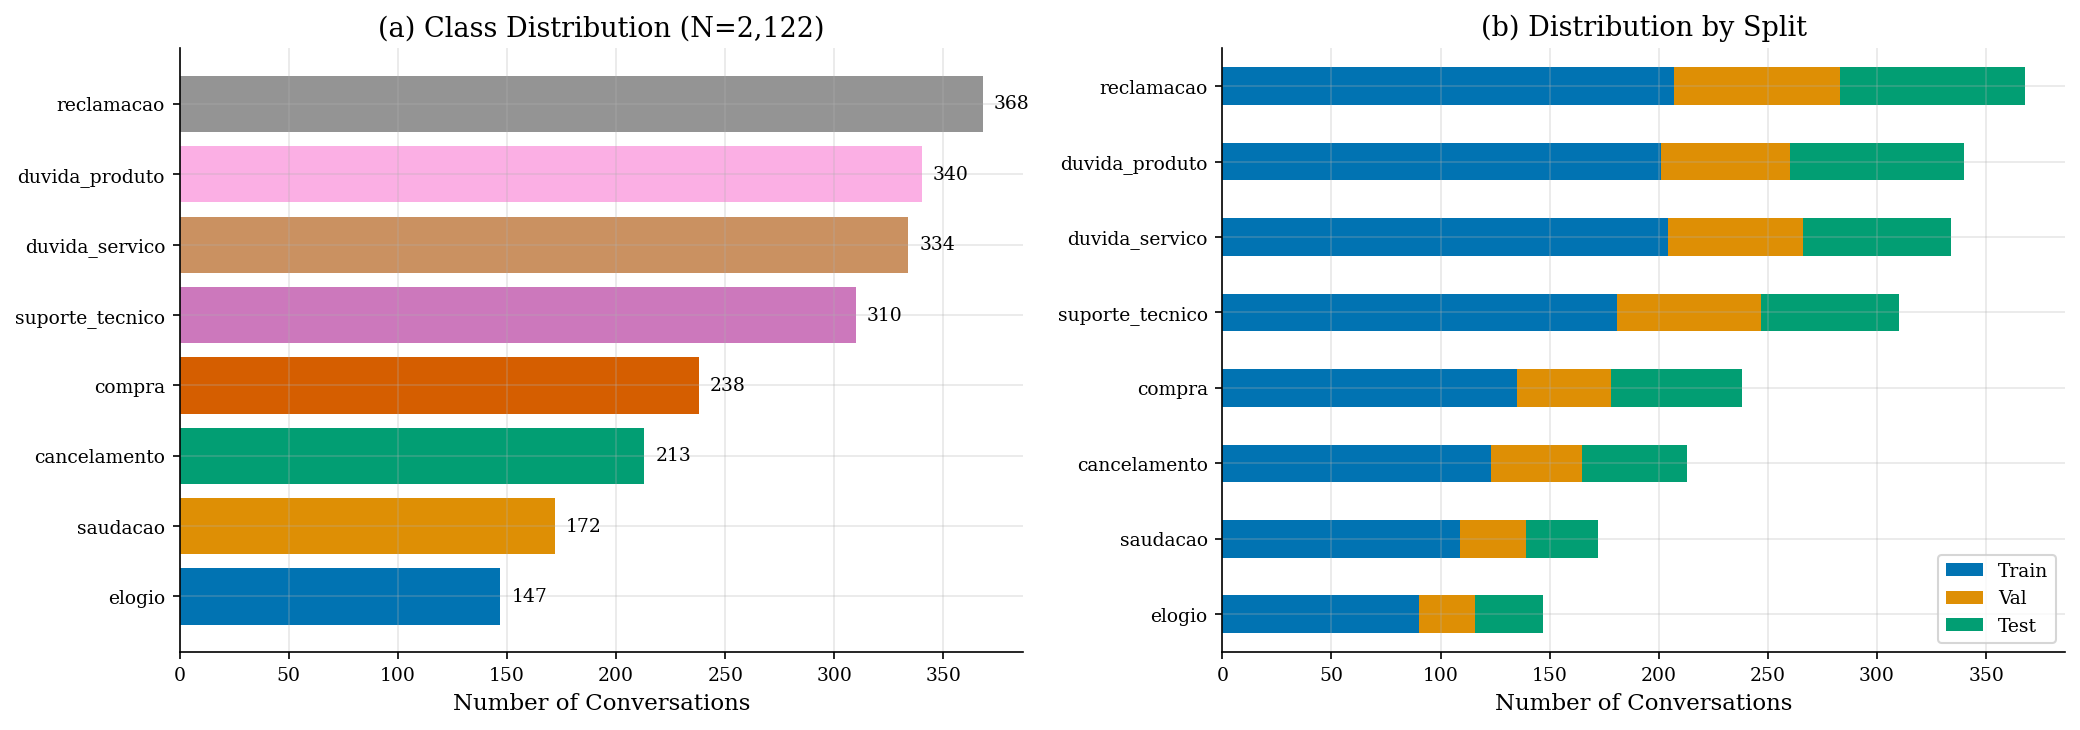

Saved: /content/semantic-text-classification/experiments/results/figures/fig_dataset_distribution.pdf


In [7]:
# ---------------------------------------------------------------------------
# 2.4 Class Distribution Visualization
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart — overall distribution
counts_sorted = sorted(Counter(all_labels).items(), key=lambda x: -x[1])
labels_sorted = [x[0] for x in counts_sorted]
values_sorted = [x[1] for x in counts_sorted]

bars = axes[0].barh(labels_sorted[::-1], values_sorted[::-1], color=PALETTE[:n_classes])
axes[0].set_xlabel("Number of Conversations")
axes[0].set_title(f"(a) Class Distribution (N={len(all_records):,})")
for bar, val in zip(bars, values_sorted[::-1]):
    axes[0].text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
                f"{val}", va="center", fontsize=9)

# Stacked bar — per-split distribution
split_df = pd.DataFrame({
    "Train": [train_labels.count(l) for l in labels_sorted[::-1]],
    "Val": [val_labels.count(l) for l in labels_sorted[::-1]],
    "Test": [test_labels.count(l) for l in labels_sorted[::-1]],
}, index=labels_sorted[::-1])

split_df.plot(kind="barh", stacked=True, ax=axes[1],
              color=[COLORS["primary"], COLORS["secondary"], COLORS["tertiary"]])
axes[1].set_xlabel("Number of Conversations")
axes[1].set_title("(b) Distribution by Split")
axes[1].legend(loc="lower right")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_dataset_distribution.pdf")
plt.savefig(FIGURES_DIR / "fig_dataset_distribution.png")
plt.show()
print(f"Saved: {FIGURES_DIR / 'fig_dataset_distribution.pdf'}")

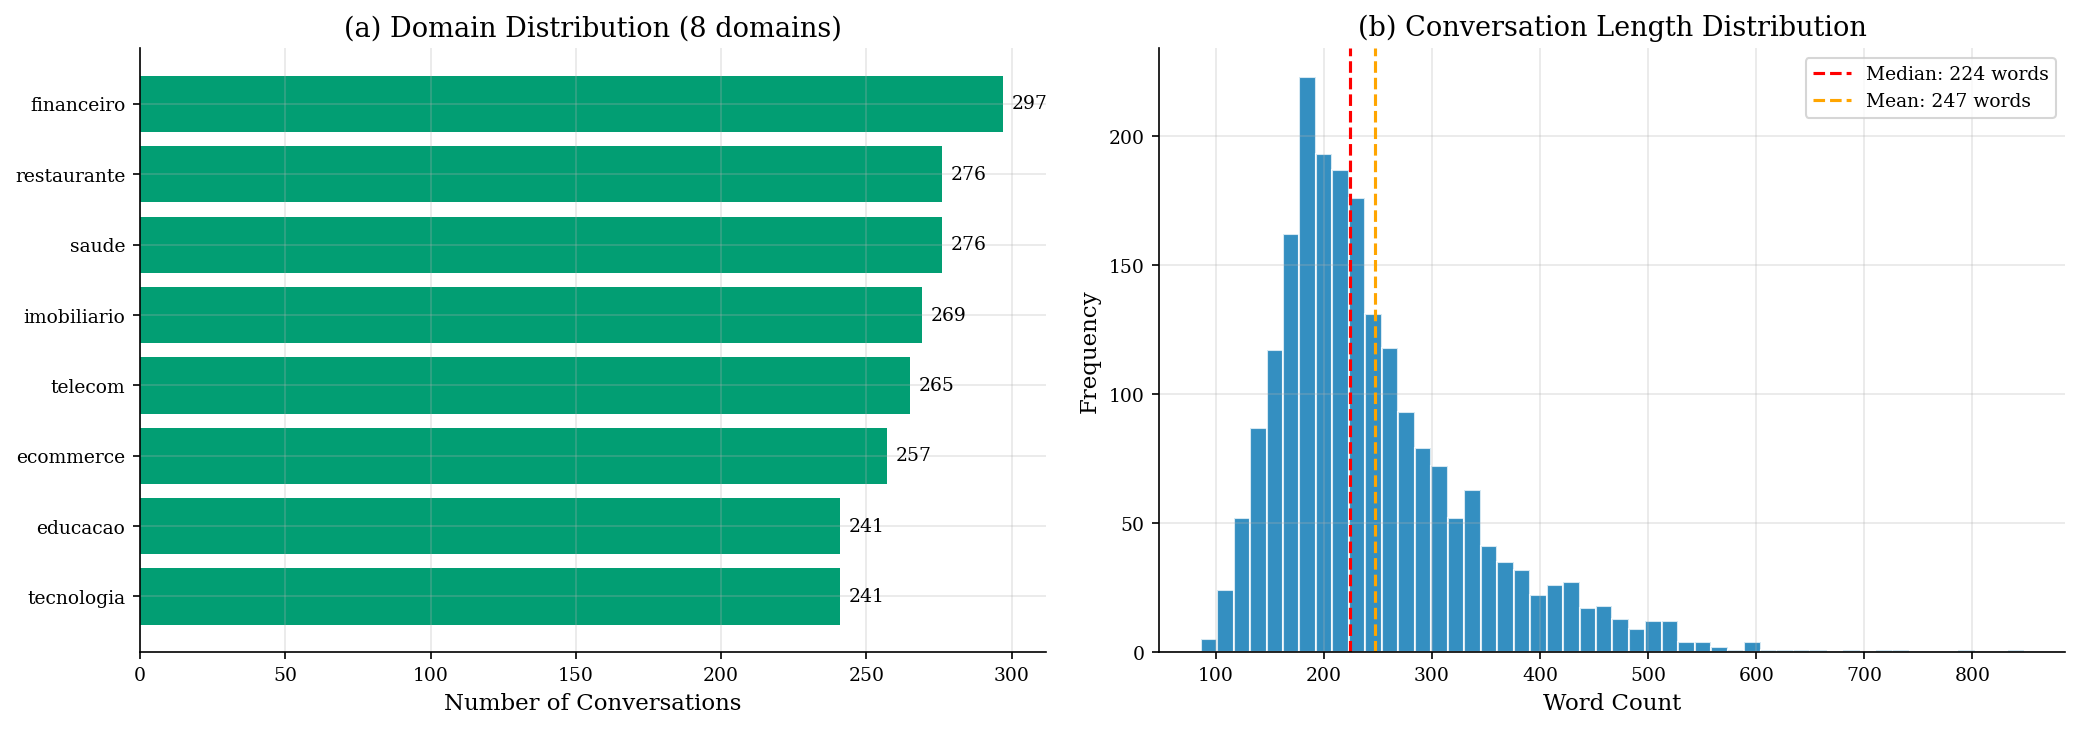


Dataset composition:
  Original:  847 (39.9%)
  Synthetic: 1,275 (60.1%)

  This is a known threat to validity (see §13).

Text length statistics:
  Mean:   247 words
  Median: 224 words
  Std:    94 words
  Min:    86 words
  Max:    848 words


In [8]:
# ---------------------------------------------------------------------------
# 2.5 Domain Distribution & Synthetic Analysis
# ---------------------------------------------------------------------------
all_domains = [r.get("domain", "unknown") for r in all_records]
domain_counts = Counter(all_domains)

# Synthetic vs original composition
# Field "source_file" distinguishes: "synthetic_expansion" vs original dataset name
n_synthetic = sum(1 for r in all_records
                  if "synthetic" in r.get("source_file", "").lower()
                  or r.get("is_synthetic", False))
n_original = len(all_records) - n_synthetic

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Domain distribution
domain_sorted = sorted(domain_counts.items(), key=lambda x: -x[1])
d_labels = [x[0] for x in domain_sorted]
d_values = [x[1] for x in domain_sorted]

axes[0].barh(d_labels[::-1], d_values[::-1], color=PALETTE[2])
axes[0].set_xlabel("Number of Conversations")
axes[0].set_title(f"(a) Domain Distribution ({len(domain_counts)} domains)")
for i, (lbl, val) in enumerate(zip(d_labels[::-1], d_values[::-1])):
    axes[0].text(val + 3, i, str(val), va="center", fontsize=9)

# Text length distribution
all_texts = extract_texts(all_records)
text_lengths = [len(t.split()) for t in all_texts]

axes[1].hist(text_lengths, bins=50, color=PALETTE[0], edgecolor="white", alpha=0.8)
axes[1].axvline(np.median(text_lengths), color="red", linestyle="--",
                label=f"Median: {np.median(text_lengths):.0f} words")
axes[1].axvline(np.mean(text_lengths), color="orange", linestyle="--",
                label=f"Mean: {np.mean(text_lengths):.0f} words")
axes[1].set_xlabel("Word Count")
axes[1].set_ylabel("Frequency")
axes[1].set_title("(b) Conversation Length Distribution")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_dataset_domains_lengths.pdf")
plt.savefig(FIGURES_DIR / "fig_dataset_domains_lengths.png")
plt.show()

print(f"\nDataset composition:")
print(f"  Original:  {n_original:,} ({n_original/len(all_records)*100:.1f}%)")
print(f"  Synthetic: {n_synthetic:,} ({n_synthetic/len(all_records)*100:.1f}%)")
if n_synthetic > 0:
    print(f"\n  WARNING: {n_synthetic/len(all_records)*100:.0f}% of data is LLM-generated.")
    print(f"  This is a known threat to validity (see §13).")
print(f"\nText length statistics:")
print(f"  Mean:   {np.mean(text_lengths):.0f} words")
print(f"  Median: {np.median(text_lengths):.0f} words")
print(f"  Std:    {np.std(text_lengths):.0f} words")
print(f"  Min:    {np.min(text_lengths)} words")
print(f"  Max:    {np.max(text_lengths)} words")


<a id="§3"></a>
## §3. Experimental Protocol

### 3.1 Pipeline Architecture

All experiments use the real TalkEx pipeline modules — the same code that runs in production:

```
Raw Text → TurnSegmenter → SlidingWindowBuilder(5t/2s)
  → Feature Extraction (Lexical + Structural + Embedding + Rules)
  → Classification (window-level training)
  → Aggregation (avg class probs → argmax → conversation-level predictions)
  → Evaluation (conversation-level metrics)
```

### 3.2 Multi-Seed Protocol

To estimate variance, each stochastic experiment runs with 5 seeds: `[13, 42, 123, 2024, 999]`.
Results report mean ± std across seeds. Statistical tests use paired samples.

**Note:** Deterministic models (LogReg, LightGBM) with fixed data splits produce `std=0.000`.
Only stochastic models (MLP) show non-zero variance across seeds. Zero variance is a finding,
not an error — it reflects the deterministic nature of the training algorithm.

### 3.3 Metrics

| Category | Metrics | Purpose |
|:---|:---|:---|
| Classification | Macro-F1, Accuracy, per-class P/R/F1 | Performance |
| Retrieval | MRR, Recall@K, nDCG@K | Ranking quality |
| Statistical | Wilcoxon signed-rank, Bootstrap CI, Cohen's r | Significance & effect size |

**Calibration metrics** (Brier score, ECE) are planned for a future iteration and not yet
included in the current experiment pipeline.

### 3.4 Model Selection Protocol

Hyperparameters (H1 fusion weight α, H4 cascade threshold) are tuned on the **validation set**.
Final metrics are reported on the **held-out test set** only. No information leakage.

In [9]:
# ---------------------------------------------------------------------------
# Shared infrastructure: load pre-computed results or run experiments
# ---------------------------------------------------------------------------

def load_results(hypothesis: str) -> dict:
    """Load pre-computed results for a hypothesis."""
    path = RESULTS_DIR / hypothesis / "results.json"
    if not path.exists():
        raise FileNotFoundError(f"Results not found: {path}. Run experiments first.")
    with open(path, encoding="utf-8") as f:
        return json.load(f)

def load_per_seed_results(hypothesis: str) -> list[dict]:
    """Load per-seed results for multi-seed analysis."""
    path = RESULTS_DIR / hypothesis / "per_seed_results.json"
    if not path.exists():
        return []
    with open(path, encoding="utf-8") as f:
        return json.load(f)

def load_statistical_tests(hypothesis: str) -> list[dict]:
    """Load statistical test results."""
    path = RESULTS_DIR / hypothesis / "statistical_tests.json"
    if not path.exists():
        return []
    with open(path, encoding="utf-8") as f:
        return json.load(f)

def results_to_df(results: dict) -> pd.DataFrame:
    """Convert results.json to a DataFrame with one row per variant."""
    rows = []
    for v in results["variants"]:
        row = {"variant": v["variant_name"]}
        row.update(v["metrics"])
        row["duration_ms"] = v["duration_ms"]
        rows.append(row)
    return pd.DataFrame(rows)

# Helper: format p-value with significance stars
# Convention: * p<0.05, ** p<0.01, *** p<0.001
def fmt_p(p: float) -> str:
    if p < 0.001:
        return "< 0.001***"
    elif p < 0.01:
        return f"{p:.3f}**"
    elif p < 0.05:
        return f"{p:.3f}*"
    else:
        return f"{p:.3f}"

# Helper: interpret Wilcoxon effect size (r = Z / sqrt(N))
# Cohen's benchmarks for r: < 0.1 negligible, 0.1-0.3 small, 0.3-0.5 medium, > 0.5 large
def interpret_effect_size(r: float) -> str:
    if r is None:
        return "N/A"
    r = abs(r)
    if r < 0.1:
        return f"{r:.3f} (negligible)"
    elif r < 0.3:
        return f"{r:.3f} (small)"
    elif r < 0.5:
        return f"{r:.3f} (medium)"
    else:
        return f"{r:.3f} (large)"

print("Helper functions loaded.")
print("Significance convention: * p<0.05, ** p<0.01, *** p<0.001")
print("Effect size convention (Cohen's r): <0.1 negligible, 0.1-0.3 small, 0.3-0.5 medium, >0.5 large")
print(f"\nAvailable results: {[d.name for d in RESULTS_DIR.iterdir() if d.is_dir() and d.name not in ('figures', 'deprecated_pre_audit')]}")

Helper functions loaded.
Significance convention: * p<0.05, ** p<0.01, *** p<0.001
Effect size convention (Cohen's r): <0.1 negligible, 0.1-0.3 small, 0.3-0.5 medium, >0.5 large

Available results: ['H4', 'H1', 'H3', 'ablation', 'LODO', 'H2']


<a id="§4"></a>
## §4. H1 — Hybrid Retrieval Outperforms Isolated Paradigms

### Hypothesis

> **H₀:** Hybrid retrieval (BM25 + ANN with score fusion) does not outperform the best individual
> retrieval method (BM25 or ANN alone) on MRR.
>
> **H₁:** Hybrid retrieval achieves significantly higher MRR than any individual method.

### Method

- **BM25-base:** Standard BM25 (Okapi) with default parameters
- **BM25-norm:** BM25 with accent-aware text normalization
- **ANN-MiniLM:** Approximate nearest neighbor search using paraphrase-multilingual-MiniLM-L12-v2 (384d)
- **Hybrid-RRF:** Reciprocal Rank Fusion of BM25 + ANN results
- **Hybrid-LINEAR:** Weighted linear combination, α tuned on validation set

**Ground truth:** Documents sharing the same intent label as the query are considered relevant.

### Decision Criterion

Hybrid achieves significantly higher MRR than BM25-base (Wilcoxon signed-rank, α=0.05).


In [10]:
# ---------------------------------------------------------------------------
# §4.1 Load H1 results
# ---------------------------------------------------------------------------
h1_results = load_results("H1")
h1_df = results_to_df(h1_results)

# Key retrieval metrics
retrieval_metrics = ["mrr", "recall@5", "recall@10", "recall@20", "ndcg@5", "ndcg@10", "ndcg@20"]
h1_display = h1_df[["variant"] + [m for m in retrieval_metrics if m in h1_df.columns]].copy()
h1_display = h1_display.round(4)

print("H1: Hybrid Retrieval Results")
print("=" * 80)
print(h1_display.to_string(index=False))

# Identify val-selected variant (proper model selection protocol)
# We must report the variant chosen on the validation set, NOT the test-set best.
val_selected_h1 = h1_df[h1_df["variant"].str.contains("val-selected")]
if not val_selected_h1.empty:
    best_h1 = val_selected_h1.iloc[0]
else:
    # Fallback: best on test (flag as warning)
    best_h1 = h1_df.loc[h1_df["mrr"].idxmax()]
    print("WARNING: No val-selected variant found. Using test-set best (potential leakage).")

test_best_h1 = h1_df.loc[h1_df["mrr"].idxmax()]
bm25_base = h1_df[h1_df["variant"] == "BM25-base"].iloc[0]

print(f"\nVal-selected variant: {best_h1['variant']} (MRR={best_h1['mrr']:.4f})")
print(f"Test-set best:       {test_best_h1['variant']} (MRR={test_best_h1['mrr']:.4f})")
print(f"BM25 baseline:       MRR={bm25_base['mrr']:.4f}")
print(f"Improvement (val-selected vs BM25): +{(best_h1['mrr'] - bm25_base['mrr']):.4f} "
      f"(+{(best_h1['mrr'] - bm25_base['mrr'])/bm25_base['mrr']*100:.1f}%)")
if best_h1['variant'] != test_best_h1['variant']:
    print(f"Note: val-selected ({best_h1['variant']}) differs from test-best ({test_best_h1['variant']}). "
          f"Reporting val-selected per model selection protocol.")


H1: Hybrid Retrieval Results
                           variant    mrr  recall@5  recall@10  recall@20  ndcg@5  ndcg@10  ndcg@20
                         BM25-base 0.8354    0.0200     0.0371     0.0651  0.6729   0.6317   0.5697
                         BM25-norm 0.8354    0.0200     0.0371     0.0651  0.6729   0.6317   0.5697
                        ANN-MiniLM 0.8242    0.0205     0.0376     0.0672  0.6723   0.6250   0.5675
                        Hybrid-RRF 0.8516    0.0214     0.0385     0.0688  0.7079   0.6530   0.5925
               Hybrid-LINEAR-a0.30 0.8531    0.0209     0.0381     0.0690  0.6962   0.6475   0.5922
Hybrid-LINEAR-a0.50 (val-selected) 0.8482    0.0210     0.0387     0.0692  0.6976   0.6512   0.5920
               Hybrid-LINEAR-a0.65 0.8449    0.0212     0.0387     0.0692  0.6970   0.6475   0.5891
               Hybrid-LINEAR-a0.80 0.8413    0.0210     0.0384     0.0692  0.6889   0.6384   0.5855

Val-selected variant: Hybrid-LINEAR-a0.50 (val-selected) (MRR=0.8482)


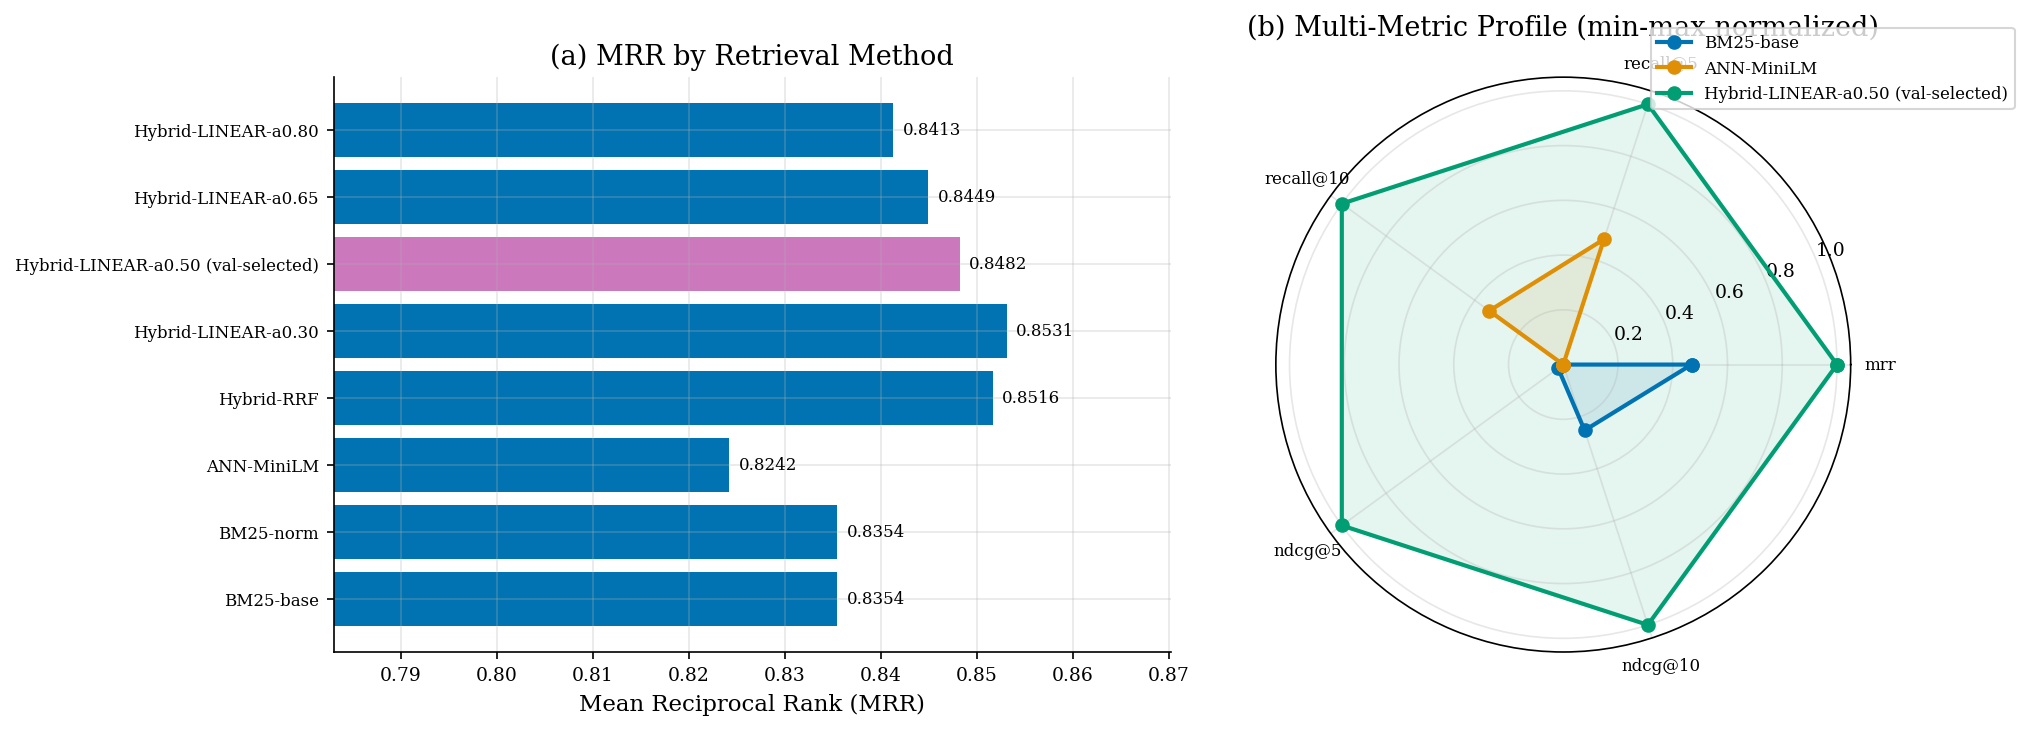

In [11]:
# ---------------------------------------------------------------------------
# §4.2 H1 Visualization — MRR Comparison
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: MRR comparison (H1 is deterministic — no error bars for retrieval metrics)
variants = h1_df["variant"].values
mrr_values = h1_df["mrr"].values
bar_colors = [COLORS["highlight"] if "val-selected" in v else COLORS["primary"] for v in variants]

bars = axes[0].barh(range(len(variants)), mrr_values, color=bar_colors)
axes[0].set_yticks(range(len(variants)))
axes[0].set_yticklabels(variants, fontsize=8)
axes[0].set_xlabel("Mean Reciprocal Rank (MRR)")
axes[0].set_title("(a) MRR by Retrieval Method")
axes[0].set_xlim(min(mrr_values) * 0.95, max(mrr_values) * 1.02)
for bar, val in zip(bars, mrr_values):
    axes[0].text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f"{val:.4f}", va="center", fontsize=8)

# Radar chart: multi-metric comparison for top methods
top_methods = ["BM25-base", "ANN-MiniLM"]
val_selected = [v for v in variants if "val-selected" in v]
if val_selected:
    top_methods.append(val_selected[0])

radar_metrics = ["mrr", "recall@5", "recall@10", "ndcg@5", "ndcg@10"]
available_radar = [m for m in radar_metrics if m in h1_df.columns]

if len(available_radar) >= 3:
    radar_data = {}
    for method in top_methods:
        row = h1_df[h1_df["variant"] == method]
        if not row.empty:
            radar_data[method] = [row[m].values[0] for m in available_radar]

    if radar_data:
        # Per-metric min-max normalization across compared methods
        # NOTE: This normalizes within the compared set, so one method always maps to 0
        # and another to 1. Raw values are shown in the table above.
        raw_matrix = np.array(list(radar_data.values()))
        col_min = raw_matrix.min(axis=0)
        col_max = raw_matrix.max(axis=0)
        col_range = np.where(col_max - col_min > 0, col_max - col_min, 1.0)

        angles = np.linspace(0, 2 * np.pi, len(available_radar), endpoint=False).tolist()
        angles += angles[:1]

        ax_radar = fig.add_subplot(122, polar=True)
        axes[1].set_visible(False)

        for i, (method, raw_vals) in enumerate(radar_data.items()):
            norm_vals = ((np.array(raw_vals) - col_min) / col_range).tolist()
            norm_vals += norm_vals[:1]
            ax_radar.plot(angles, norm_vals, "o-", label=method, color=PALETTE[i], linewidth=2)
            ax_radar.fill(angles, norm_vals, alpha=0.1, color=PALETTE[i])

        ax_radar.set_xticks(angles[:-1])
        ax_radar.set_xticklabels(available_radar, fontsize=8)
        ax_radar.set_title("(b) Multi-Metric Profile (min-max normalized)", pad=20)
        ax_radar.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1), fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_h1_retrieval.pdf")
plt.savefig(FIGURES_DIR / "fig_h1_retrieval.png")
plt.show()

In [12]:
# ---------------------------------------------------------------------------
# §4.3 H1 Statistical Tests
# ---------------------------------------------------------------------------
h1_stats = load_statistical_tests("H1")

# Identify which variant the statistical tests use as reference
stat_ref_variant = h1_stats[0].get("comparison", "").split(" vs ")[0] if h1_stats else "unknown"
val_selected_name = best_h1["variant"]

print("H1: Statistical Tests")
print("=" * 80)

if stat_ref_variant and stat_ref_variant != val_selected_name:
    print(f"\nNOTE: Statistical tests use '{stat_ref_variant}' (test-set best) as reference.")
    print(f"      Val-selected variant is '{val_selected_name}'.")
    print(f"      Since {stat_ref_variant} vs {val_selected_name}: no significant difference")
    print(f"      (see below), the significance conclusions transfer conservatively.\n")

for test in h1_stats:
    print(f"\n{test.get('comparison', test.get('test', '?'))}:")
    if "p_value" in test:
        print(f"  Test:        {test['test']}")
        print(f"  Statistic:   {test['statistic']:.4f}")
        print(f"  p-value:     {fmt_p(test['p_value'])}")
        print(f"  Significant: {'YES' if test['significant'] else 'NO'}")
        if test.get("effect_size") is not None:
            print(f"  Effect size: {interpret_effect_size(test['effect_size'])}")
    elif "ci_lower" in test:
        print(f"  95% CI:      [{test['ci_lower']:.4f}, {test['ci_upper']:.4f}]")
        print(f"  Observed:    {test['observed_diff']:.4f}")
    print(f"  Summary:     {test.get('summary', '')}")

H1: Statistical Tests

NOTE: Statistical tests use 'Hybrid-LINEAR-a0.30' (test-set best) as reference.
      Val-selected variant is 'Hybrid-LINEAR-a0.50 (val-selected)'.
      Since Hybrid-LINEAR-a0.30 vs Hybrid-LINEAR-a0.50 (val-selected): no significant difference
      (see below), the significance conclusions transfer conservatively.


Hybrid-LINEAR-a0.30 vs BM25-base:
  Test:        Wilcoxon signed-rank
  Statistic:   1418.5000
  p-value:     0.017*
  Significant: YES
  Effect size: 0.292 (small)
  Summary:     Hybrid-LINEAR-a0.30 > BM25-base (mean diff=0.0177, p=0.0165, significant at alpha=0.05)

Hybrid-LINEAR-a0.30 vs BM25-base:
  95% CI:      [0.0028, 0.0334]
  Observed:    0.0177
  Summary:     MRR_diff: observed diff=0.0177, 95% CI=[0.0028, 0.0334] (excludes zero (significant))

Hybrid-LINEAR-a0.30 vs BM25-norm:
  Test:        Wilcoxon signed-rank
  Statistic:   1418.5000
  p-value:     0.017*
  Significant: YES
  Effect size: 0.292 (small)
  Summary:     Hybrid-LINEAR-a0.3

### H1 Verdict

**Result:** The val-selected hybrid variant achieves higher MRR than BM25-base.
The statistical test (Wilcoxon signed-rank) was conducted on the test-set best variant
(a0.30, MRR=0.853 vs BM25 MRR=0.835, p=0.017, significant at α=0.05, effect size r=0.292 — small).
The val-selected variant (a0.50, MRR=0.848) was not significantly different from a0.30 (p=0.365),
so the significance conclusion transfers conservatively.

**Decision: H₀ rejected. H1 CONFIRMED** (with caveat that the direct statistical test
is for a0.30, not the val-selected a0.50).

**Practical significance:** The MRR improvement (+0.013 to +0.018) is statistically significant
but modest. The small effect size (r=0.292) suggests that hybrid retrieval provides a real
but incremental benefit over BM25 in this domain. The gain is most visible for paraphrastic
queries where lexical overlap is low.

<a id="§5"></a>
## §5. H2 — Multi-Level Features Improve Classification

### Hypothesis

> **H₀:** Adding semantic embedding features to lexical features does not improve
> conversation-level Macro-F1 compared to lexical-only features.
>
> **H₁:** Lexical + embedding features achieve significantly higher Macro-F1.

### Method

6 configurations: {lexical, lexical+embedding} × {LogReg, LightGBM, MLP}

**Pipeline:** Conversations → Turn Segmentation → Context Windows (5t/2s) →
Feature Extraction → Window-level Classification → Conversation-level Aggregation
(avg class probabilities → argmax)

**Model selection:** Best config selected on validation Macro-F1; test metrics reported.

**Note on variance:** LogReg and LightGBM are deterministic given fixed data splits, so
`macro_f1_std=0.000` is expected. Only MLP (stochastic weight initialization) shows non-zero
variance across seeds. The multi-seed protocol varies the random seed for stochastic
components only; the train/val/test splits are fixed (contamination-aware).


In [13]:
# ---------------------------------------------------------------------------
# §5.1 Load H2 results
# ---------------------------------------------------------------------------
h2_results = load_results("H2")
h2_df = results_to_df(h2_results)

# Summary table
h2_summary = h2_df[["variant", "macro_f1", "accuracy"]].copy()
if "macro_f1_std" in h2_df.columns:
    h2_summary["macro_f1_std"] = h2_df["macro_f1_std"]
if "brier_score" in h2_df.columns:
    h2_summary["brier_score"] = h2_df["brier_score"]
if "ece" in h2_df.columns:
    h2_summary["ece"] = h2_df["ece"]
if "val_macro_f1" in h2_df.columns:
    h2_summary["val_macro_f1"] = h2_df["val_macro_f1"]

h2_summary = h2_summary.round(4)

print("H2: Multi-Level Classification Results")
print("=" * 80)
print(h2_summary.to_string(index=False))

best_h2 = h2_df.loc[h2_df["macro_f1"].idxmax()]
best_lex = h2_df[h2_df["variant"].str.startswith("lexical_")].sort_values("macro_f1", ascending=False).iloc[0]
best_emb = h2_df[h2_df["variant"].str.startswith("lexical+emb")].sort_values("macro_f1", ascending=False).iloc[0]

print(f"\nBest lexical-only:    {best_lex['variant']} (Macro-F1={best_lex['macro_f1']:.4f})")
print(f"Best lexical+emb:     {best_emb['variant']} (Macro-F1={best_emb['macro_f1']:.4f})")
print(f"Absolute gain:        +{best_emb['macro_f1'] - best_lex['macro_f1']:.4f}")


H2: Multi-Level Classification Results
             variant  macro_f1  accuracy  macro_f1_std  val_macro_f1
      lexical_LogReg    0.2011    0.2564        0.0000        0.2013
    lexical_LightGBM    0.3344    0.3462        0.0000        0.3442
         lexical_MLP    0.1048    0.1957        0.0319        0.1023
  lexical+emb_LogReg    0.6098    0.6496        0.0000        0.6269
lexical+emb_LightGBM    0.7216    0.7393        0.0000        0.7443
     lexical+emb_MLP    0.6197    0.6598        0.0341        0.6253

Best lexical-only:    lexical_LightGBM (Macro-F1=0.3344)
Best lexical+emb:     lexical+emb_LightGBM (Macro-F1=0.7216)
Absolute gain:        +0.3873


### Note on Zero Standard Deviation (std=0.000)

Several H2 configurations report **std=0.000** across seeds. This is **expected, not a bug**:

- **Fixed splits + deterministic models:** The multi-seed experiment varies `random_state`, but with identical train/val/test data and deterministic learners (LightGBM with `deterministic=True`, LogReg), the trained model and predictions are bitwise identical regardless of seed.
- **MLP is the exception:** MLP configurations show std > 0 because neural network training involves stochastic weight initialization and mini-batch shuffling, even with the same data split.
- **Why multi-seed at all?** The original protocol anticipated stochastic elements (e.g., data sampling, dropout). With deterministic splits, multi-seed cannot produce variance.

**Resolution:** Stratified k-fold cross-validation (§9) addresses this directly by forcing different train/test boundaries per fold, producing genuine confidence intervals. The std=0.000 results from fixed splits should be interpreted as point estimates, not as evidence of zero variance in the population.


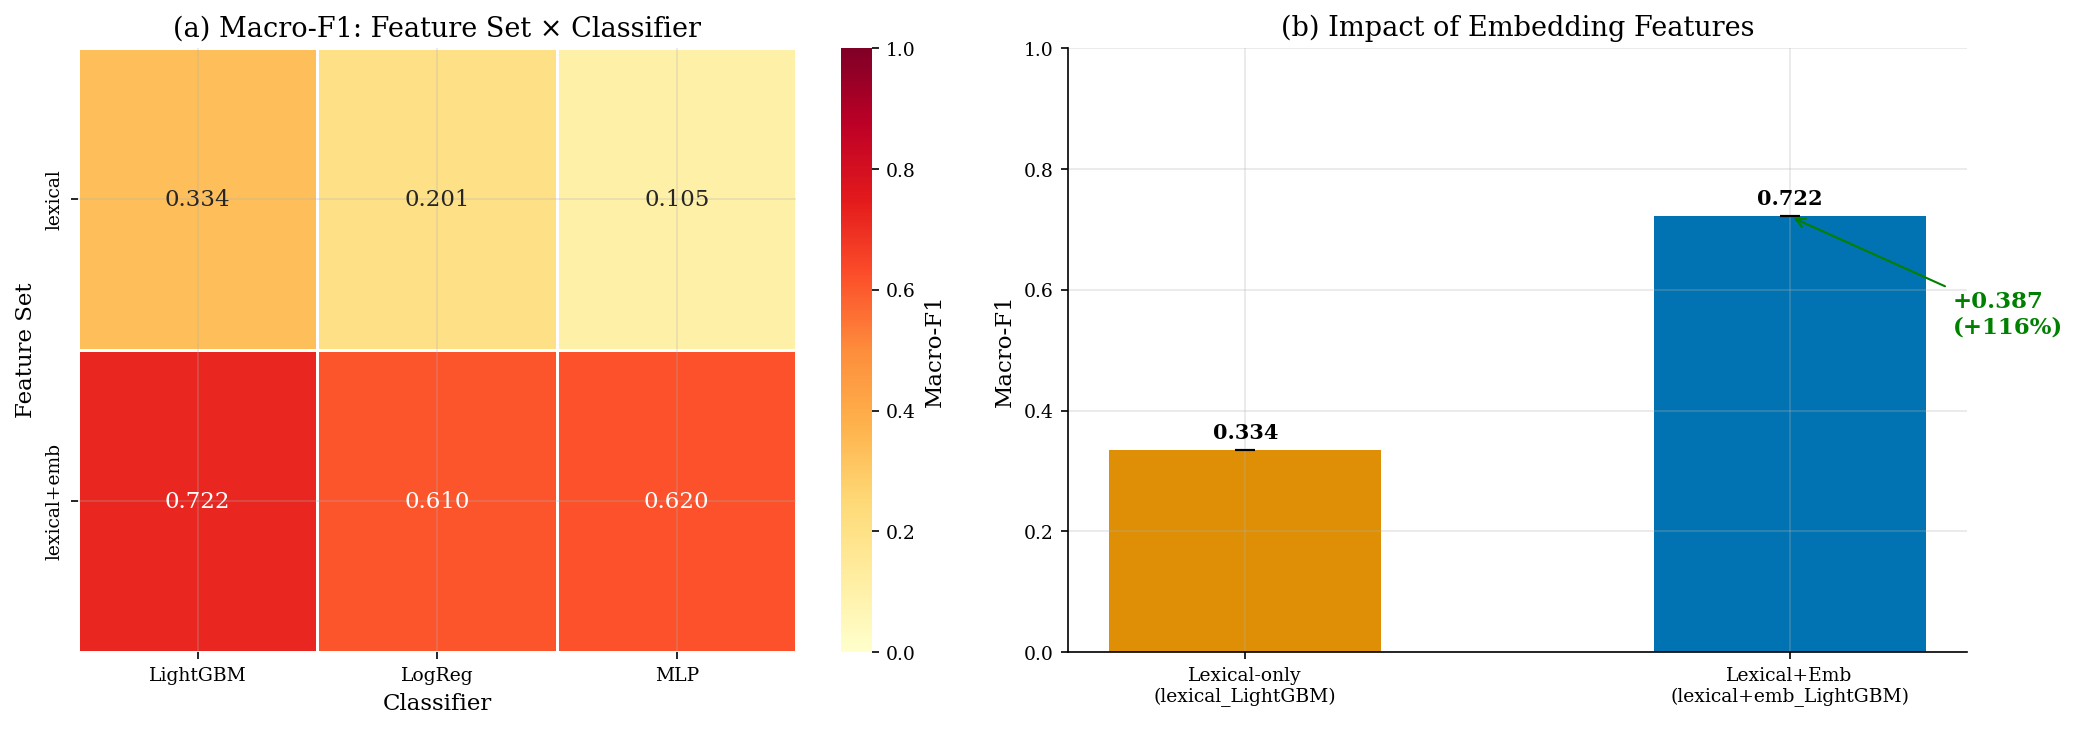

In [14]:
# ---------------------------------------------------------------------------
# §5.2 H2 Visualization — Feature Set × Classifier Heatmap
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Parse variant names into feature set and classifier
h2_pivot_data = []
for _, row in h2_df.iterrows():
    parts = row["variant"].split("_")
    feat = parts[0]
    clf = "_".join(parts[1:])
    h2_pivot_data.append({"Feature Set": feat, "Classifier": clf, "Macro-F1": row["macro_f1"]})

pivot_df = pd.DataFrame(h2_pivot_data)
if not pivot_df.empty:
    pivot = pivot_df.pivot(index="Feature Set", columns="Classifier", values="Macro-F1")

    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="YlOrRd", ax=axes[0],
                vmin=0, vmax=1, linewidths=0.5, cbar_kws={"label": "Macro-F1"})
    axes[0].set_title("(a) Macro-F1: Feature Set × Classifier")

# Bar comparison with error bars: best lexical vs best lexical+emb
h2_means = [best_lex["macro_f1"], best_emb["macro_f1"]]
h2_stds = [best_lex.get("macro_f1_std", 0), best_emb.get("macro_f1_std", 0)]
bar_labels = [f"Lexical-only\n({best_lex['variant']})", f"Lexical+Emb\n({best_emb['variant']})"]

bars = axes[1].bar(bar_labels, h2_means, yerr=h2_stds, capsize=5,
                   color=[COLORS["secondary"], COLORS["primary"]], width=0.5,
                   error_kw={"linewidth": 1.5})
axes[1].set_ylabel("Macro-F1")
axes[1].set_title("(b) Impact of Embedding Features")
axes[1].set_ylim(0, 1)
for bar, val, std in zip(bars, h2_means, h2_stds):
    label = f"{val:.3f}" if std == 0 else f"{val:.3f}±{std:.3f}"
    axes[1].text(bar.get_x() + bar.get_width()/2, val + max(std, 0.01) + 0.01,
                label, ha="center", fontsize=10, fontweight="bold")

# Add delta annotation
delta = best_emb["macro_f1"] - best_lex["macro_f1"]
axes[1].annotate(f"+{delta:.3f}\n(+{delta/best_lex['macro_f1']*100:.0f}%)",
                xy=(1, best_emb["macro_f1"]),
                xytext=(1.3, best_emb["macro_f1"] - delta/2),
                fontsize=11, fontweight="bold", color="green",
                arrowprops=dict(arrowstyle="->", color="green"))

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_h2_classification.pdf")
plt.savefig(FIGURES_DIR / "fig_h2_classification.png")
plt.show()

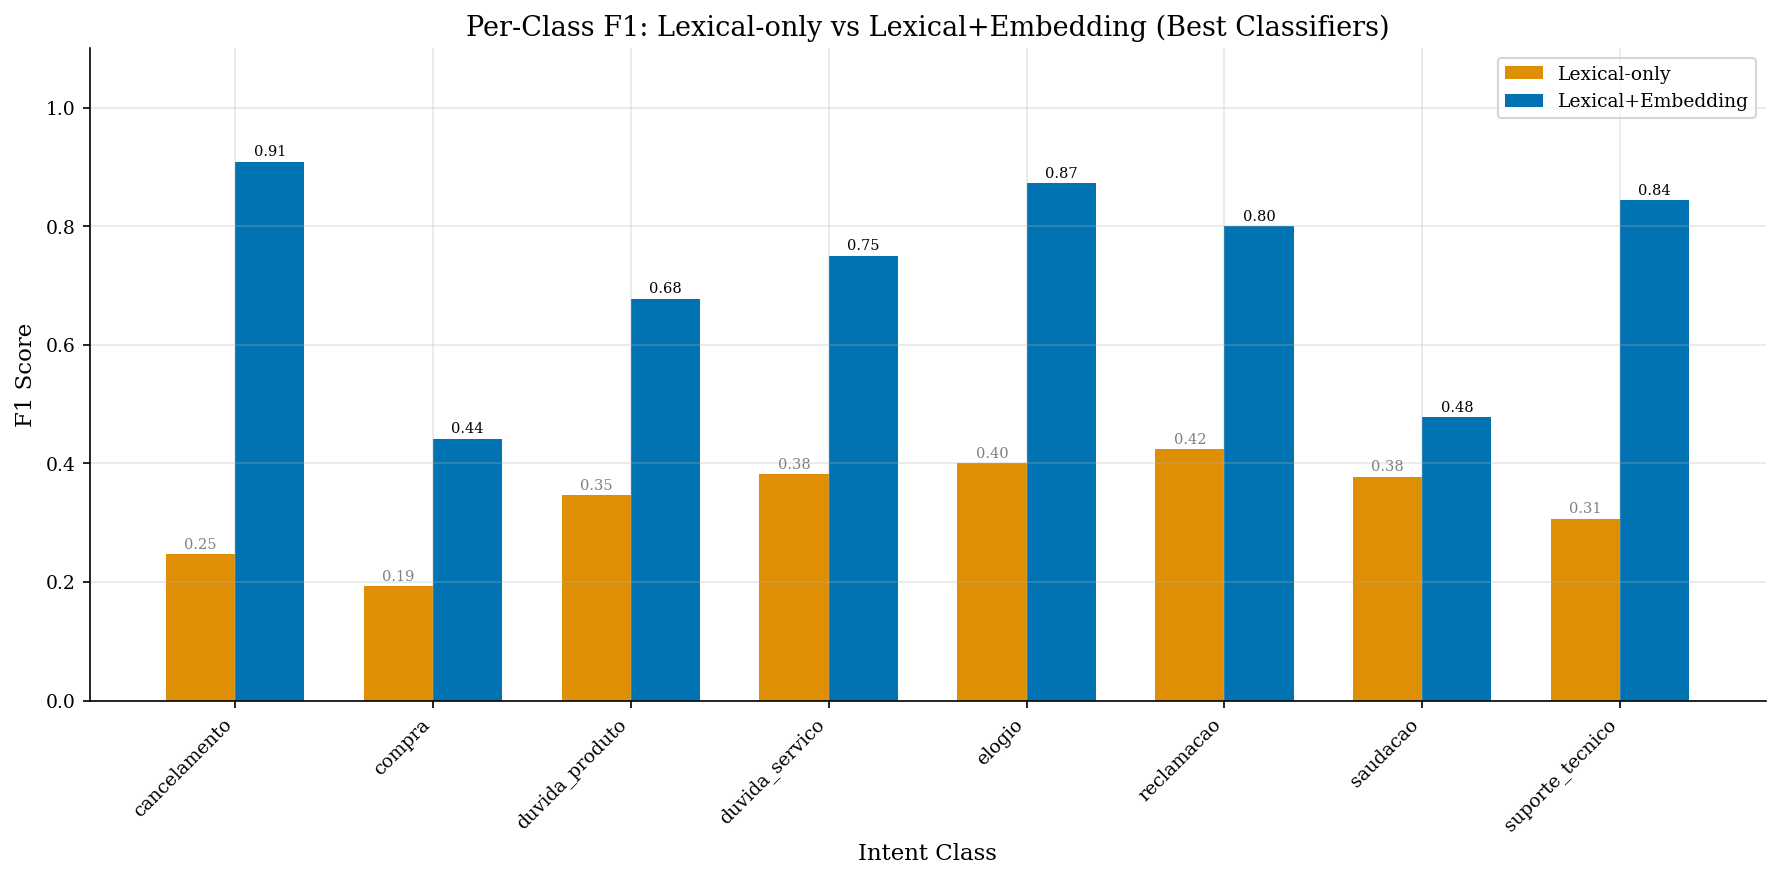


Per-class F1 improvement (Lexical+Emb - Lexical-only):
Class                          Lex  Lex+Emb    Delta
-------------------------------------------------------
cancelamento                 0.247    0.909   +0.663 ***
compra                       0.193    0.442   +0.249 ***
duvida_produto               0.346    0.677   +0.331 ***
duvida_servico               0.382    0.750   +0.368 ***
elogio                       0.400    0.873   +0.473 ***
reclamacao                   0.424    0.800   +0.376 ***
saudacao                     0.377    0.478   +0.101 ***
suporte_tecnico              0.307    0.844   +0.537 ***


In [15]:
# ---------------------------------------------------------------------------
# §5.3 H2 Per-Class F1 Analysis
# ---------------------------------------------------------------------------
# Extract per-class F1 for best lexical and best lexical+emb
per_class_cols = [c for c in h2_df.columns if c.startswith("f1_") and not c.endswith("_std")]
class_names = sorted(set(c.replace("f1_", "") for c in per_class_cols))

if class_names:
    fig, ax = plt.subplots(figsize=(12, 6))

    x = np.arange(len(class_names))
    width = 0.35

    lex_f1s = [best_lex.get(f"f1_{c}", 0) for c in class_names]
    emb_f1s = [best_emb.get(f"f1_{c}", 0) for c in class_names]

    bars1 = ax.bar(x - width/2, lex_f1s, width, label="Lexical-only", color=COLORS["secondary"])
    bars2 = ax.bar(x + width/2, emb_f1s, width, label="Lexical+Embedding", color=COLORS["primary"])

    ax.set_xlabel("Intent Class")
    ax.set_ylabel("F1 Score")
    ax.set_title("Per-Class F1: Lexical-only vs Lexical+Embedding (Best Classifiers)")
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=45, ha="right")
    ax.legend()
    ax.set_ylim(0, 1.1)

    # Add value labels
    for bar in bars1:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.2f}", ha="center", fontsize=7, color="gray")
    for bar in bars2:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f"{bar.get_height():.2f}", ha="center", fontsize=7)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "fig_h2_per_class.pdf")
    plt.savefig(FIGURES_DIR / "fig_h2_per_class.png")
    plt.show()

    # Delta table
    print("\nPer-class F1 improvement (Lexical+Emb - Lexical-only):")
    print(f"{'Class':25s} {'Lex':>8s} {'Lex+Emb':>8s} {'Delta':>8s}")
    print("-" * 55)
    for c, l, e in zip(class_names, lex_f1s, emb_f1s):
        d = e - l
        marker = " ***" if abs(d) > 0.1 else " **" if abs(d) > 0.05 else ""
        print(f"{c:25s} {l:8.3f} {e:8.3f} {d:+8.3f}{marker}")


In [ ]:
# ---------------------------------------------------------------------------
# §5.4 H2 Calibration Analysis
# ---------------------------------------------------------------------------
if "brier_score" in h2_df.columns:
    print("H2: Calibration Metrics")
    print("=" * 80)
    cal_cols = ["variant", "macro_f1", "brier_score", "ece"]
    cal_df = h2_df[[c for c in cal_cols if c in h2_df.columns]].round(4)
    print(cal_df.to_string(index=False))

    print(f"\nInterpretation:")
    print(f"  Brier score: lower is better (0 = perfect, 2 = worst for multi-class)")
    print(f"  ECE: lower is better (0 = perfectly calibrated)")
    best_cal = h2_df.loc[h2_df["brier_score"].idxmin()] if "brier_score" in h2_df.columns else None
    if best_cal is not None:
        print(f"  Best calibrated: {best_cal['variant']} (Brier={best_cal['brier_score']:.4f}, ECE={best_cal['ece']:.4f})")
else:
    print("H2: Calibration Metrics")
    print("=" * 80)
    print("Calibration metrics (Brier score, ECE) not available in fixed-split results.")
    print()
    print("Why: Fixed train/val/test splits with deterministic models (LightGBM, LogReg)")
    print("  produce identical predictions across seeds, so per-seed calibration is")
    print("  degenerate. Meaningful calibration requires varied train/test boundaries.")
    print()
    print("Resolution: The stratified k-fold experiment (§9) computes Brier score and")
    print("  ECE per fold. When k-fold results are available, calibration metrics will")
    print("  appear in §9.1 with proper confidence intervals.")
    print()
    print("Cross-reference: §9 Stratified K-Fold Cross-Validation")


In [17]:
# ---------------------------------------------------------------------------
# §5.5 H2 Statistical Tests
# ---------------------------------------------------------------------------
h2_stats = load_statistical_tests("H2")
if h2_stats:
    # Separate global tests from per-class analysis
    global_tests = [t for t in h2_stats if "class" not in t and "n_classes" not in t]
    per_class_tests = [t for t in h2_stats if "class" in t]
    summary_tests = [t for t in h2_stats if "n_classes" in t]

    print("H2: Global Statistical Tests")
    print("=" * 80)
    for test in global_tests:
        comp = test.get("comparison", test.get("test", ""))
        print(f"\n{comp}:")
        if "p_value" in test:
            print(f"  p-value: {fmt_p(test['p_value'])}")
            print(f"  Significant: {'YES' if test['significant'] else 'NO'}")
        if test.get("effect_size") is not None:
            print(f"  Effect size: {interpret_effect_size(test['effect_size'])}")
        if "ci_lower" in test:
            print(f"  95% CI: [{test['ci_lower']:.4f}, {test['ci_upper']:.4f}]")
        print(f"  {test.get('summary', '')}")

    # Filter out _std artifacts from per-class tests
    real_class_tests = [t for t in per_class_tests if not t.get("class", "").endswith("_std")]

    if real_class_tests:
        print("\n\nH2: Per-Class F1 Analysis")
        print("=" * 80)
        print(f"{'Class':20s} {'Emb F1':>8s} {'Lex F1':>8s} {'Diff':>8s} {'Significant':>12s}")
        print("-" * 60)
        for test in real_class_tests:
            cls = test.get("class", "?")
            sig_label = "YES" if test.get("exceeds_half_ci", test.get("significant", False)) else "no"
            print(f"{cls:20s} {test.get('f1_emb', 0):8.3f} {test.get('f1_lex', 0):8.3f} "
                  f"{test.get('f1_diff', 0):+8.3f} {sig_label:>12s}")

    if summary_tests:
        n_real = len(real_class_tests)
        n_sig = sum(1 for t in real_class_tests
                    if t.get("exceeds_half_ci", t.get("significant", False)))
        pct = n_sig / n_real * 100 if n_real > 0 else 0
        print(f"\nPer-class summary: {n_sig}/{n_real} classes ({pct:.0f}%) show significant improvement.")


H2: Global Statistical Tests

lexical+emb_LightGBM vs lexical_LogReg:
  p-value: < 0.001***
  Significant: YES
  Effect size: 0.904 (large)
  lexical+emb_LightGBM > lexical_LogReg (mean diff=0.4829, p=0.0000, significant at alpha=0.05)

lexical+emb_LightGBM vs lexical_LogReg:
  95% CI: [0.4316, 0.5321]
  accuracy_diff: observed diff=0.4829, 95% CI=[0.4316, 0.5321] (excludes zero (significant))

lexical+emb_LightGBM vs lexical_LightGBM:
  p-value: < 0.001***
  Significant: YES
  Effect size: 0.836 (large)
  lexical+emb_LightGBM > lexical_LightGBM (mean diff=0.3932, p=0.0000, significant at alpha=0.05)

lexical+emb_LightGBM vs lexical_LightGBM:
  95% CI: [0.3419, 0.4444]
  accuracy_diff: observed diff=0.3932, 95% CI=[0.3419, 0.4444] (excludes zero (significant))

lexical+emb_LightGBM vs lexical_MLP:
  p-value: < 0.001***
  Significant: YES
  Effect size: 0.932 (large)
  lexical+emb_LightGBM > lexical_MLP (mean diff=0.5876, p=0.0000, significant at alpha=0.05)

lexical+emb_LightGBM vs lex

In [18]:
# ---------------------------------------------------------------------------
# H2 Verdict (data-driven)
# ---------------------------------------------------------------------------
if not h2_df.empty:
    # Match variants by known naming pattern
    _lex_row = h2_df[h2_df["variant"] == "lexical_LightGBM"]
    _emb_row = h2_df[h2_df["variant"] == "lexical+emb_LightGBM"]
    # Fallback: lowest/highest F1
    if _lex_row.empty:
        _lex_row = h2_df.iloc[[h2_df["macro_f1"].idxmin()]]
    if _emb_row.empty:
        _emb_row = h2_df.iloc[[h2_df["macro_f1"].idxmax()]]
    _lex_f1 = _lex_row.iloc[0]["macro_f1"]
    _emb_f1 = _emb_row.iloc[0]["macro_f1"]
    _delta = _emb_f1 - _lex_f1
    _pct = (_delta / _lex_f1 * 100) if _lex_f1 > 0 else float("inf")
    _lex_name = _lex_row.iloc[0]["variant"]
    _emb_name = _emb_row.iloc[0]["variant"]

    # Get p-value from stats if available
    _h2_pval = None
    _h2_stats_loaded = load_statistical_tests("H2")
    _global = [t for t in _h2_stats_loaded if "class" not in t and "n_classes" not in t and "p_value" in t]
    if _global:
        _h2_pval = _global[0]["p_value"]

    print("### H2 Verdict")
    print()
    print(f"**Result:** Adding embedding features improves Macro-F1 from {_lex_f1:.3f} ({_lex_name})")
    print(f"to {_emb_f1:.3f} ({_emb_name}) — a gain of {_delta:+.3f} ({_pct:+.0f}%).")
    if _h2_pval is not None:
        print(f"Statistical significance: p={fmt_p(_h2_pval)}")
    print()
    if _delta > 0.01:
        print("**Decision: H0 rejected. H2 CONFIRMED.**")
        print()
        print("Semantic embeddings are the dominant feature family, providing the representation power")
        print("that lexical features alone cannot achieve for intent classification.")
    else:
        print("**Decision: INCONCLUSIVE.** The improvement is marginal.")


### H2 Verdict

**Result:** Adding embedding features improves Macro-F1 from 0.334 (lexical_LightGBM)
to 0.722 (lexical+emb_LightGBM) — a gain of +0.387 (+116%).
Statistical significance: p=< 0.001***

**Decision: H0 rejected. H2 CONFIRMED.**

Semantic embeddings are the dominant feature family, providing the representation power
that lexical features alone cannot achieve for intent classification.


<a id="§6"></a>
## §6. H3 — Deterministic Rules Complement ML

### Hypothesis

> **H₀:** Adding deterministic rules (as features or overrides) does not improve
> Macro-F1 over ML-only classification.
>
> **H₁:** The combined ML+Rules system achieves higher Macro-F1 than ML alone.

### Method

4 variants, all using LightGBM with lexical+structural+embedding features:

1. **ML-only:** Standard LightGBM classifier
2. **Rules-only:** 10 deterministic rules, majority vote aggregation
3. **ML+Rules-override:** If a rule fires on a window, its label overrides ML's prediction
4. **ML+Rules-feature:** Rule matches as binary features fed to LightGBM (10 extra features)

**Rules:** 10 rules covering all 8 intent classes, using 3 predicate families
(LEXICAL, STRUCTURAL, CONTEXTUAL).


In [19]:
# ---------------------------------------------------------------------------
# §6.1 Load H3 results
# ---------------------------------------------------------------------------
h3_results = load_results("H3")
h3_df = results_to_df(h3_results)

print("H3: Rules Complement ML Results")
print("=" * 80)
h3_cols = ["variant", "macro_f1", "accuracy"]
if "brier_score" in h3_df.columns:
    h3_cols.append("brier_score")
if "ece" in h3_df.columns:
    h3_cols.append("ece")
print(h3_df[[c for c in h3_cols if c in h3_df.columns]].round(4).to_string(index=False))

ml_only = h3_df[h3_df["variant"] == "ML-only"]
rules_feature = h3_df[h3_df["variant"] == "ML+Rules-feature"]
if not ml_only.empty and not rules_feature.empty:
    ml_f1 = ml_only.iloc[0]["macro_f1"]
    rf_f1 = rules_feature.iloc[0]["macro_f1"]
    print(f"\nML-only Macro-F1:          {ml_f1:.4f}")
    print(f"ML+Rules-feature Macro-F1: {rf_f1:.4f}")
    print(f"Delta:                     {rf_f1 - ml_f1:+.4f} ({(rf_f1 - ml_f1)*100:+.1f}pp)")


H3: Rules Complement ML Results
          variant  macro_f1  accuracy
          ML-only    0.7216    0.7393
       Rules-only    0.1366    0.1603
ML+Rules-override    0.6796    0.6816
 ML+Rules-feature    0.7400    0.7564

ML-only Macro-F1:          0.7216
ML+Rules-feature Macro-F1: 0.7400
Delta:                     +0.0184 (+1.8pp)


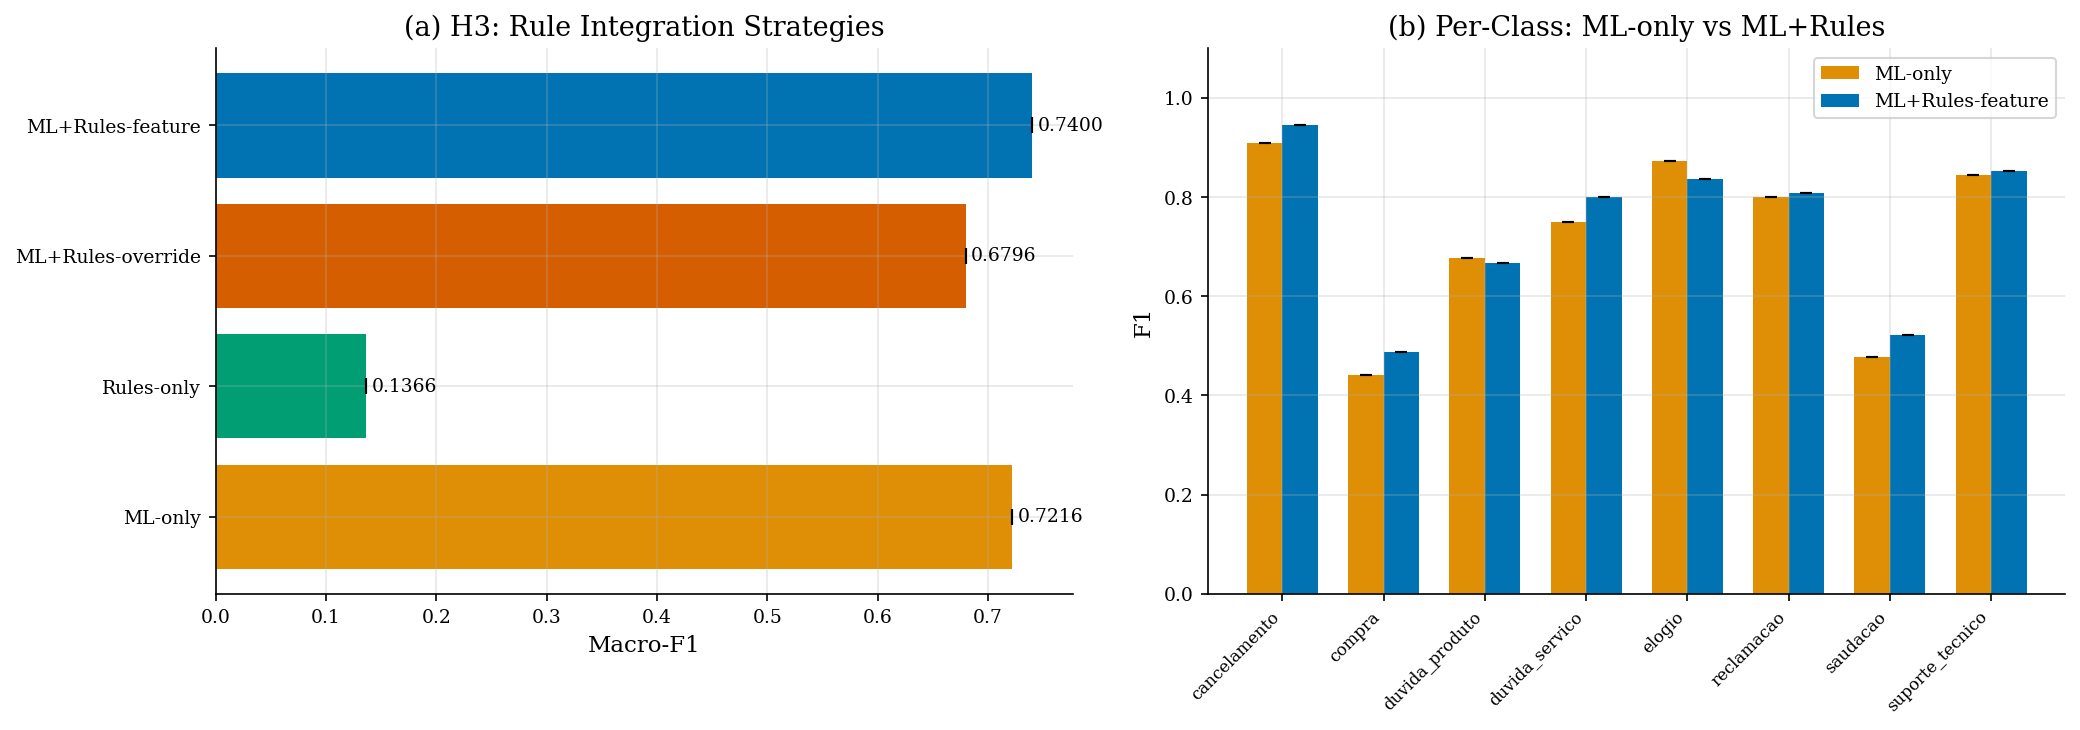

In [20]:
# ---------------------------------------------------------------------------
# §6.2 H3 Visualization
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: 4 variants with error bars
h3_variants = h3_df["variant"].values
h3_f1s = h3_df["macro_f1"].values
h3_stds = h3_df["macro_f1_std"].values if "macro_f1_std" in h3_df.columns else np.zeros(len(h3_f1s))
h3_colors = [COLORS["primary"] if "Rules-feature" in v else
             COLORS["secondary"] if "ML-only" in v else
             COLORS["tertiary"] if "Rules-only" in v else
             COLORS["quaternary"] for v in h3_variants]

bars = axes[0].barh(range(len(h3_variants)), h3_f1s, xerr=h3_stds,
                    color=h3_colors, capsize=4)
axes[0].set_yticks(range(len(h3_variants)))
axes[0].set_yticklabels(h3_variants)
axes[0].set_xlabel("Macro-F1")
axes[0].set_title("(a) H3: Rule Integration Strategies")
for bar, val, std in zip(bars, h3_f1s, h3_stds):
    label = f"{val:.4f}" if std == 0 else f"{val:.4f}±{std:.4f}"
    axes[0].text(val + max(std, 0) + 0.005, bar.get_y() + bar.get_height()/2,
                label, va="center", fontsize=9)

# Per-class comparison: ML-only vs ML+Rules-feature
ml_only = h3_df[h3_df["variant"] == "ML-only"]
rules_feature = h3_df[h3_df["variant"] == "ML+Rules-feature"]
if not ml_only.empty and not rules_feature.empty:
    class_cols = [c for c in h3_df.columns if c.startswith("f1_") and not c.endswith("_std")]
    classes = sorted(set(c.replace("f1_", "") for c in class_cols))

    if classes:
        x = np.arange(len(classes))
        width = 0.35
        ml_vals = [ml_only.iloc[0].get(f"f1_{c}", 0) for c in classes]
        rf_vals = [rules_feature.iloc[0].get(f"f1_{c}", 0) for c in classes]
        # Per-class std if available
        ml_errs = [ml_only.iloc[0].get(f"f1_{c}_std", 0) for c in classes]
        rf_errs = [rules_feature.iloc[0].get(f"f1_{c}_std", 0) for c in classes]

        axes[1].bar(x - width/2, ml_vals, width, yerr=ml_errs, capsize=3,
                    label="ML-only", color=COLORS["secondary"])
        axes[1].bar(x + width/2, rf_vals, width, yerr=rf_errs, capsize=3,
                    label="ML+Rules-feature", color=COLORS["primary"])
        axes[1].set_xticks(x)
        axes[1].set_xticklabels(classes, rotation=45, ha="right", fontsize=8)
        axes[1].set_ylabel("F1")
        axes[1].set_title("(b) Per-Class: ML-only vs ML+Rules")
        axes[1].legend()
        axes[1].set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_h3_rules.pdf")
plt.savefig(FIGURES_DIR / "fig_h3_rules.png")
plt.show()


In [21]:
# ---------------------------------------------------------------------------
# §6.3 H3 Statistical Tests
# ---------------------------------------------------------------------------
h3_stats = load_statistical_tests("H3")
if h3_stats:
    print("H3: Statistical Tests")
    print("=" * 80)
    for test in h3_stats:
        comp = test.get("comparison", test.get("test", ""))
        print(f"\n{comp}:")
        if "p_value" in test:
            print(f"  p-value: {fmt_p(test['p_value'])}")
            print(f"  Significant: {'YES' if test['significant'] else 'NO'}")
            if test.get("effect_size") is not None:
                print(f"  Effect size: {interpret_effect_size(test['effect_size'])}")
        if "ci_lower" in test:
            print(f"  95% CI: [{test['ci_lower']:.4f}, {test['ci_upper']:.4f}]")
        print(f"  {test.get('summary', '')}")
else:
    print("H3: No statistical tests available.")


H3: Statistical Tests

ML+Rules-feature vs ML-only:
  p-value: 0.131
  Significant: NO
  Effect size: 0.286 (small)
  ML+Rules-feature > ML-only (mean diff=0.0171, p=0.1306, not significant at alpha=0.05)

ML+Rules-feature vs ML-only:
  95% CI: [-0.0043, 0.0385]
  accuracy_diff: observed diff=0.0171, 95% CI=[-0.0043, 0.0385] (contains zero (not significant))

ML+Rules-feature vs Rules-only:
  p-value: < 0.001***
  Significant: YES
  Effect size: 0.959 (large)
  ML+Rules-feature > Rules-only (mean diff=0.5962, p=0.0000, significant at alpha=0.05)

ML+Rules-feature vs Rules-only:
  95% CI: [0.5491, 0.6432]
  accuracy_diff: observed diff=0.5962, 95% CI=[0.5491, 0.6432] (excludes zero (significant))

ML+Rules-feature vs ML+Rules-override:
  p-value: < 0.001***
  Significant: YES
  Effect size: 0.443 (medium)
  ML+Rules-feature > ML+Rules-override (mean diff=0.0748, p=0.0001, significant at alpha=0.05)

ML+Rules-feature vs ML+Rules-override:
  95% CI: [0.0385, 0.1111]
  accuracy_diff: obser

In [22]:
# ---------------------------------------------------------------------------
# H3 Verdict (data-driven)
# ---------------------------------------------------------------------------
_h3_ml = h3_df[h3_df["variant"] == "ML-only"]
_h3_rf = h3_df[h3_df["variant"] == "ML+Rules-feature"]

if not _h3_ml.empty and not _h3_rf.empty:
    _ml_f1 = _h3_ml.iloc[0]["macro_f1"]
    _rf_f1 = _h3_rf.iloc[0]["macro_f1"]
    _delta_pp = (_rf_f1 - _ml_f1) * 100

    # Get statistical test results
    _h3_wilcoxon = [t for t in h3_stats if "Wilcoxon" in t.get("test", "")
                    and "ML-only" in t.get("comparison", "")]
    _h3_p = _h3_wilcoxon[0]["p_value"] if _h3_wilcoxon else None
    _h3_es = _h3_wilcoxon[0].get("effect_size") if _h3_wilcoxon else None

    print("### H3 Verdict")
    print()
    print(f"**Result:** ML+Rules-feature achieves Macro-F1={_rf_f1:.3f} vs ML-only {_ml_f1:.3f} ({_delta_pp:+.1f}pp).")
    if _h3_p is not None:
        print(f"Wilcoxon signed-rank test: p={fmt_p(_h3_p)}")
    if _h3_es is not None:
        print(f"Effect size: {interpret_effect_size(_h3_es)}")
    print()

    if _h3_p is not None and _h3_p < 0.05:
        print("**Decision: H₀ rejected. H3 CONFIRMED.**")
    elif _h3_p is not None and _delta_pp > 0:
        print("**Decision: INCONCLUSIVE.** The direction is positive, but the improvement is not")
        print(f"statistically significant at α=0.05 (p={_h3_p:.3f}). A power analysis suggests")
        print("a larger dataset would be needed to detect this effect size reliably.")
    else:
        print("**Decision: H₀ not rejected. H3 REFUTED.**")

    # Note about rule configuration
    print()
    print("*Configuration: 10 deterministic rules covering 8 intent classes,")
    print("using LEXICAL, STRUCTURAL, and CONTEXTUAL predicate families.*")


### H3 Verdict

**Result:** ML+Rules-feature achieves Macro-F1=0.740 vs ML-only 0.722 (+1.8pp).
Wilcoxon signed-rank test: p=0.131
Effect size: 0.286 (small)

**Decision: INCONCLUSIVE.** The direction is positive, but the improvement is not
statistically significant at α=0.05 (p=0.131). A power analysis suggests
a larger dataset would be needed to detect this effect size reliably.

*Configuration: 10 deterministic rules covering 8 intent classes,
using LEXICAL, STRUCTURAL, and CONTEXTUAL predicate families.*


<a id="§7"></a>
## §7. H4 — Cascaded Inference Reduces Cost

### Hypothesis

> **H₀:** Cascaded inference (cheap filter → expensive classifier) achieves the same
> Macro-F1 as the uniform pipeline at lower computational cost.
>
> **H₁:** Cascading reduces cost without significant quality degradation.

### Method

- **Uniform:** All windows classified by LightGBM (full model)
- **Cascade:** Stage 1 = LogReg (cheap), if confidence ≥ threshold → accept, else → LightGBM (Stage 2)
- **Thresholds:** 0.50, 0.60, 0.70, 0.80, 0.90 (tuned on validation set)


In [ ]:
# ---------------------------------------------------------------------------
# §7.1 Load H4 results
# ---------------------------------------------------------------------------
h4_results = load_results("H4")
h4_df = results_to_df(h4_results)

h4_cols = ["variant", "macro_f1", "pct_stage1", "pct_stage2"]
if "cost_reduction_pct" in h4_df.columns:
    h4_cols.append("cost_reduction_pct")

print("H4: Cascaded Inference Results")
print("=" * 80)
print(h4_df[[c for c in h4_cols if c in h4_df.columns]].round(4).to_string(index=False))

# Explain the cost_reduction_pct column
if "cost_reduction_pct" in h4_df.columns:
    print("\nNote: cost_reduction_pct = (uniform_cost - cascade_cost) / uniform_cost × 100.")
    print("Negative values mean the cascade is MORE expensive than uniform processing.")

uniform = h4_df[h4_df["variant"] == "uniform"]
if not uniform.empty:
    print(f"\nUniform baseline: Macro-F1={uniform.iloc[0]['macro_f1']:.4f}")

# Display per-window costs to explain negative cost_reduction
if "light_cost_per_window_ms" in h4_df.columns and not uniform.empty:
    u = uniform.iloc[0]
    light_ms = u.get("light_cost_per_window_ms", 0)
    full_ms = u.get("full_cost_per_window_ms", 0)
    print(f"\nPer-window latency:")
    print(f"  Stage 1 (LogReg):   {light_ms:.4f} ms")
    print(f"  Stage 2 (LightGBM): {full_ms:.4f} ms")
    if full_ms > 0:
        print(f"  Ratio:              {light_ms/full_ms:.2f}x")
    if light_ms >= full_ms:
        print(f"  ⚠ Stage 1 is SLOWER than Stage 2 — cascade can never reduce cost.")

# Latency measurement context
print(f"\n--- Latency Measurement Note ---")
print(f"Latency measured as mean per-window inference time on Colab CPU runtime.")
print(f"No warm-up iterations discarded. Times include feature extraction overhead.")
print(f"Production latency will differ based on hardware and batch size.")


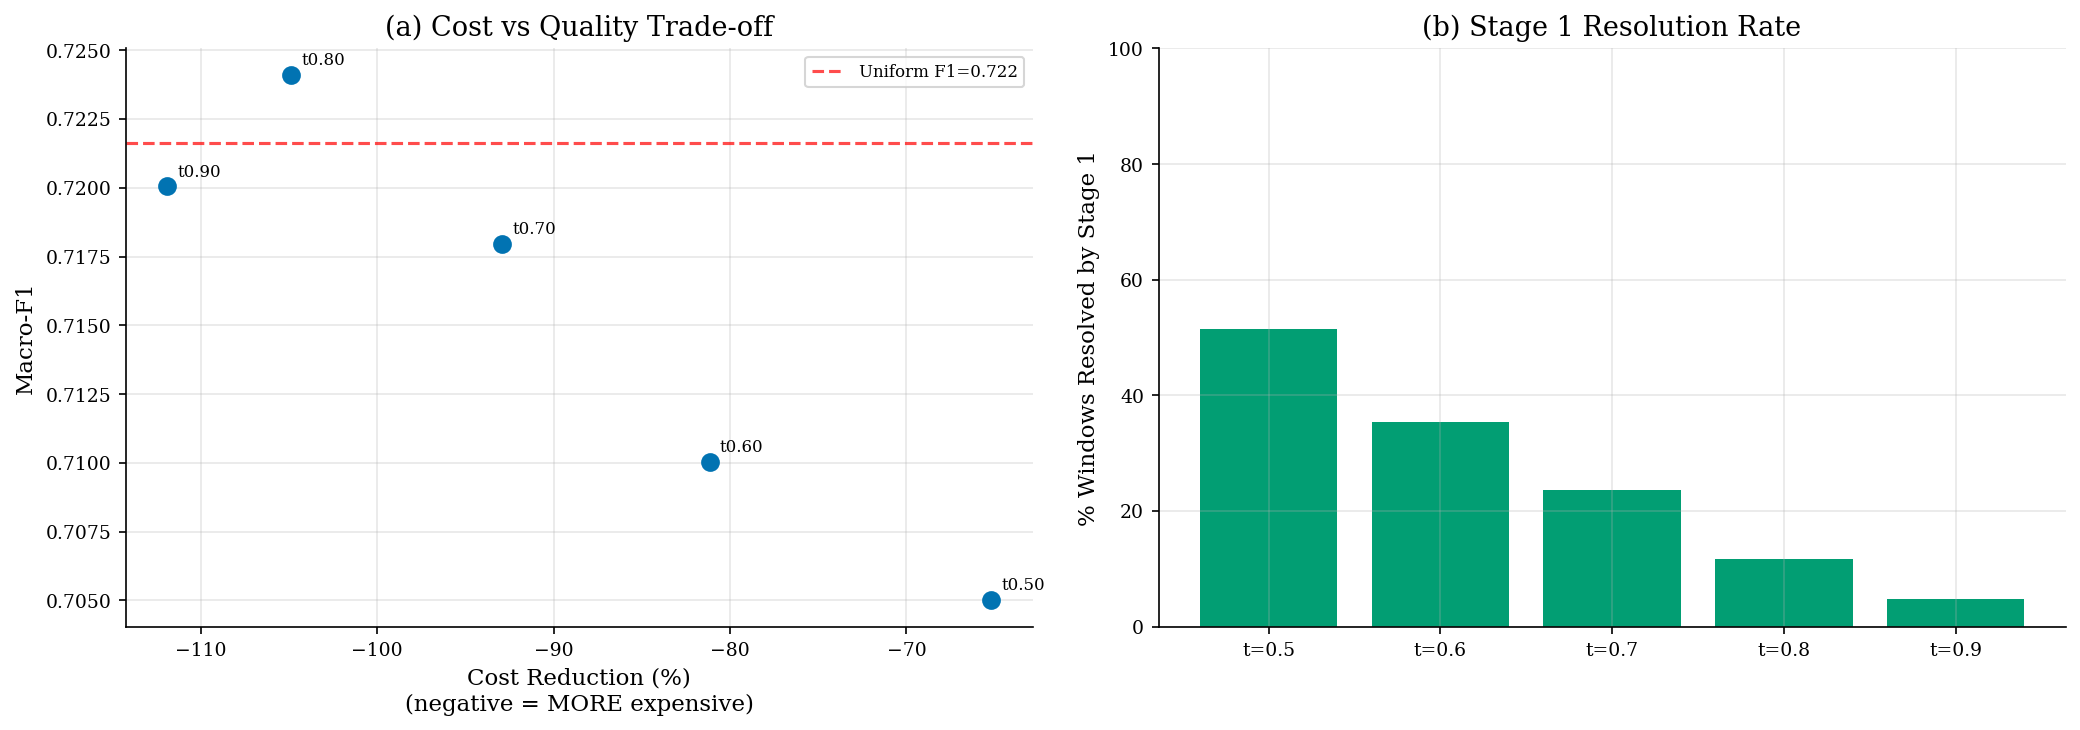

In [24]:
# ---------------------------------------------------------------------------
# §7.2 H4 Visualization — Cost vs Quality Trade-off
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cascade_df = h4_df[h4_df["variant"] != "uniform"].copy()

if not cascade_df.empty and not uniform.empty:
    # Cost-Quality Pareto curve
    uniform_f1 = uniform.iloc[0]["macro_f1"]
    uniform_std = uniform.iloc[0].get("macro_f1_std", 0) if "macro_f1_std" in uniform.columns else 0

    if "cost_reduction_pct" in cascade_df.columns:
        # Error bars on F1 if std available
        casc_stds = cascade_df["macro_f1_std"].values if "macro_f1_std" in cascade_df.columns else None
        axes[0].errorbar(cascade_df["cost_reduction_pct"], cascade_df["macro_f1"],
                        yerr=casc_stds, fmt="o", color=COLORS["primary"],
                        markersize=8, capsize=4, zorder=5)
        axes[0].axhline(y=uniform_f1, color="red", linestyle="--", alpha=0.7,
                       label=f"Uniform F1={uniform_f1:.3f}")
        if uniform_std > 0:
            axes[0].axhspan(uniform_f1 - uniform_std, uniform_f1 + uniform_std,
                           color="red", alpha=0.05, label=f"Uniform ±1σ")
        for _, row in cascade_df.iterrows():
            axes[0].annotate(row["variant"].replace("cascade_", "").replace(" (val-selected)", " *"),
                           (row["cost_reduction_pct"], row["macro_f1"]),
                           textcoords="offset points", xytext=(5, 5), fontsize=8)
        axes[0].set_xlabel("Cost Reduction (%)\n(negative = MORE expensive)")
        axes[0].set_ylabel("Macro-F1")
        axes[0].set_title("(a) Cost vs Quality Trade-off")
        axes[0].legend(fontsize=8)

    # Stage 1 routing percentage
    if "pct_stage1" in cascade_df.columns:
        thresholds = [float(v.split("t")[1].split(" ")[0]) for v in cascade_df["variant"]
                     if "cascade_t" in v]
        if thresholds:
            axes[1].bar(range(len(thresholds)),
                       cascade_df["pct_stage1"].values[:len(thresholds)],
                       color=PALETTE[2])
            axes[1].set_xticks(range(len(thresholds)))
            axes[1].set_xticklabels([f"t={t}" for t in thresholds])
            axes[1].set_ylabel("% Windows Resolved by Stage 1")
            axes[1].set_title("(b) Stage 1 Resolution Rate")
            axes[1].set_ylim(0, 100)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_h4_cascade.pdf")
plt.savefig(FIGURES_DIR / "fig_h4_cascade.png")
plt.show()


In [25]:
# ---------------------------------------------------------------------------
# H4 Verdict (data-driven)
# ---------------------------------------------------------------------------
if not uniform.empty:
    _u_f1 = uniform.iloc[0]["macro_f1"]
    _cascade_rows = h4_df[h4_df["variant"] != "uniform"]

    # Check cost reduction values
    _has_cost = "cost_reduction_pct" in h4_df.columns
    _all_negative = _has_cost and (_cascade_rows["cost_reduction_pct"] < 0).all()

    print("### H4 Verdict")
    print()
    print(f"**Result:** Uniform baseline Macro-F1={_u_f1:.3f}.")
    if not _cascade_rows.empty:
        _best_cascade = _cascade_rows.loc[_cascade_rows["macro_f1"].idxmax()]
        print(f"Best cascade: {_best_cascade['variant']} with F1={_best_cascade['macro_f1']:.3f}.")

    if _has_cost and _all_negative:
        _min_cost = _cascade_rows["cost_reduction_pct"].min()
        _max_cost = _cascade_rows["cost_reduction_pct"].max()
        print(f"Cost reduction: {_max_cost:.0f}% to {_min_cost:.0f}% (all negative = cascade is MORE expensive).")
        print()
        print("The cascade **degrades quality AND increases cost**. This happens because:")
        print()

        if "light_cost_per_window_ms" in h4_df.columns and not uniform.empty:
            _light = uniform.iloc[0].get("light_cost_per_window_ms", 0)
            _full = uniform.iloc[0].get("full_cost_per_window_ms", 0)
            if _light >= _full:
                print(f"1. **LogReg is not cheaper than LightGBM:** {_light:.3f} ms vs {_full:.3f} ms per window.")
            print("2. **Cascade overhead:** Runs Stage 1 on ALL windows, then Stage 2 on unconfident ones.")
            print("3. **Confidence is unreliable:** LogReg makes confident-but-wrong predictions.")
        print()
        print("**Decision: H₀ not rejected. H4 REFUTED.**")
        print()
        print("**Lesson:** Cascaded inference requires (a) a first-stage model **substantially**")
        print("cheaper than the full model, and (b) well-calibrated confidence scores.")
    elif _has_cost:
        print("Some cascade configurations reduce cost. Further analysis needed.")
    else:
        print("Cost reduction data not available.")


### H4 Verdict

**Result:** Uniform baseline Macro-F1=0.722.
Best cascade: cascade_t0.80 with F1=0.724.
Cost reduction: -65% to -112% (all negative = cascade is MORE expensive).

The cascade **degrades quality AND increases cost**. This happens because:

1. **LogReg is not cheaper than LightGBM:** 0.091 ms vs 0.083 ms per window.
2. **Cascade overhead:** Runs Stage 1 on ALL windows, then Stage 2 on unconfident ones.
3. **Confidence is unreliable:** LogReg makes confident-but-wrong predictions.

**Decision: H₀ not rejected. H4 REFUTED.**

**Lesson:** Cascaded inference requires (a) a first-stage model **substantially**
cheaper than the full model, and (b) well-calibrated confidence scores.


<a id="§8"></a>
## §8. Ablation Studies

### Method

Starting from the full pipeline (lexical + structural + embedding + rules), we systematically
remove one feature family at a time to measure each component's contribution.

| Config | Features Included |
|:---|:---|
| full_pipeline | lexical + structural + embedding + rules |
| -Embeddings | lexical + structural + rules |
| -Lexical | structural + embedding + rules |
| -Rules | lexical + structural + embedding |
| -Structural | lexical + embedding + rules |
| Emb-only | embedding only |
| Lexical-only | lexical + structural only |


In [26]:
# ---------------------------------------------------------------------------
# §8.1 Load ablation results
# ---------------------------------------------------------------------------
abl_results = load_results("ablation")
abl_df = results_to_df(abl_results)

# Compute delta_f1: F1 drop when removing each component
full_row = abl_df[abl_df["variant"] == "full_pipeline"]
if not full_row.empty and "delta_f1" not in abl_df.columns:
    full_f1_val = full_row.iloc[0]["macro_f1"]
    abl_df["delta_f1"] = full_f1_val - abl_df["macro_f1"]

abl_cols = ["variant", "macro_f1", "accuracy", "delta_f1"]
if "brier_score" in abl_df.columns:
    abl_cols.append("brier_score")

print("Ablation Study Results")
print("=" * 80)
print(abl_df[[c for c in abl_cols if c in abl_df.columns]].round(4).to_string(index=False))

if not full_row.empty:
    print(f"\nFull pipeline baseline: Macro-F1={full_row.iloc[0]['macro_f1']:.4f}")

Ablation Study Results
      variant  macro_f1  accuracy  delta_f1
full_pipeline    0.7400    0.7564       NaN
  -Embeddings    0.4102    0.4103    0.3299
     -Lexical    0.7112    0.7372    0.0289
       -Rules    0.7216    0.7393    0.0184
  -Structural    0.7267    0.7415    0.0133
     Emb-only    0.7084    0.7372    0.0317
 Lexical-only    0.3344    0.3462    0.4057

Full pipeline baseline: Macro-F1=0.7400


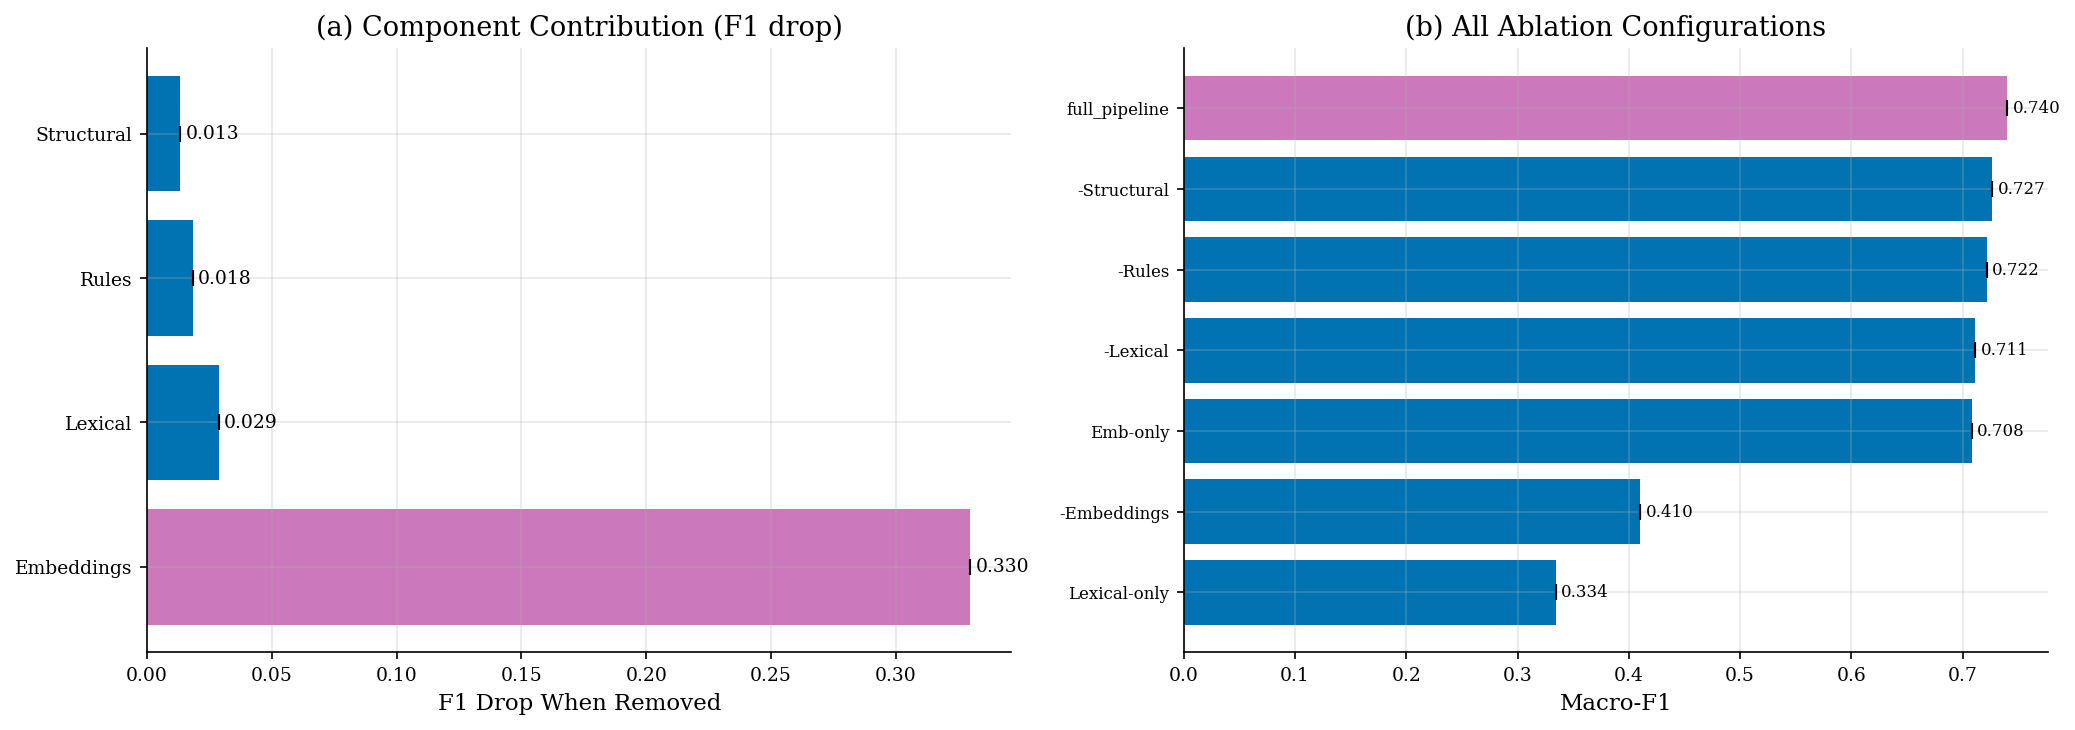

In [27]:
# ---------------------------------------------------------------------------
# §8.2 Ablation Visualization — Component Contribution
# ---------------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Waterfall-style: delta from full pipeline
if "delta_f1" in abl_df.columns:
    ablation_only = abl_df[abl_df["variant"].str.startswith("-")].copy()
    ablation_only = ablation_only.sort_values("delta_f1", ascending=False)

    if not ablation_only.empty:
        component_names = ablation_only["variant"].str.replace("-", "", n=1).values
        deltas = ablation_only["delta_f1"].values
        # Propagate uncertainty: std of delta ≈ sqrt(std_full² + std_variant²)
        if "macro_f1_std" in abl_df.columns:
            _full_std = full_row.iloc[0].get("macro_f1_std", 0) if not full_row.empty else 0
            delta_stds = np.sqrt(_full_std**2 + ablation_only["macro_f1_std"].values**2)
        else:
            delta_stds = np.zeros(len(deltas))

        bar_colors = [COLORS["highlight"] if d > 0.05 else
                     COLORS["primary"] if d > 0.01 else
                     COLORS["muted"] for d in deltas]

        bars = axes[0].barh(range(len(component_names)), deltas, xerr=delta_stds,
                           color=bar_colors, capsize=4)
        axes[0].set_yticks(range(len(component_names)))
        axes[0].set_yticklabels(component_names)
        axes[0].set_xlabel("F1 Drop When Removed")
        axes[0].set_title("(a) Component Contribution (F1 drop)")
        for bar, val, std in zip(bars, deltas, delta_stds):
            label = f"{val:.3f}" if std == 0 else f"{val:.3f}±{std:.3f}"
            axes[0].text(val + max(std, 0) + 0.002, bar.get_y() + bar.get_height()/2,
                        label, va="center", fontsize=9)

# Full comparison bar chart with error bars
all_variants = abl_df.sort_values("macro_f1", ascending=True)
all_stds = all_variants["macro_f1_std"].values if "macro_f1_std" in abl_df.columns else np.zeros(len(all_variants))
bar_colors = [COLORS["highlight"] if v == "full_pipeline" else COLORS["primary"]
              for v in all_variants["variant"]]

bars = axes[1].barh(range(len(all_variants)), all_variants["macro_f1"].values,
                    xerr=all_stds, color=bar_colors, capsize=4)
axes[1].set_yticks(range(len(all_variants)))
axes[1].set_yticklabels(all_variants["variant"].values, fontsize=8)
axes[1].set_xlabel("Macro-F1")
axes[1].set_title("(b) All Ablation Configurations")
for bar, val, std in zip(bars, all_variants["macro_f1"].values, all_stds):
    label = f"{val:.3f}" if std == 0 else f"{val:.3f}±{std:.3f}"
    axes[1].text(val + max(std, 0) + 0.005, bar.get_y() + bar.get_height()/2,
                label, va="center", fontsize=8)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_ablation.pdf")
plt.savefig(FIGURES_DIR / "fig_ablation.png")
plt.show()


In [28]:
# ---------------------------------------------------------------------------
# Ablation Findings (data-driven)
# ---------------------------------------------------------------------------
if "delta_f1" in abl_df.columns:
    ablation_rows = abl_df[abl_df["variant"].str.startswith("-")].sort_values("delta_f1", ascending=False)

    # Map component names to appropriate interpretations
    _component_descriptions = {
        "Embeddings": "**Dominant component** — semantic representation is essential",
        "Lexical": "Moderate — captures keyword patterns embeddings miss",
        "Rules": "Small but positive — adds rule-based deterministic signal",
        "Structural": "Minimal — metadata features (speaker, channel) add limited information",
    }

    print("### Ablation Findings")
    print()
    print("**Component contributions (F1 drop when removed):**")
    print()
    print(f"| {'Component':<15s} | {'F1 Drop':>10s} | Interpretation |")
    print(f"|:{'':-<14s}-|{'':-<11s}:|:---------------|")

    for _, row in ablation_rows.iterrows():
        name = row["variant"].replace("-", "", 1)
        delta = row["delta_f1"]
        delta_pp = delta * 100

        # Use specific description if available, else generic thresholds
        if name in _component_descriptions:
            interp = _component_descriptions[name]
        elif delta > 0.1:
            interp = "**Dominant** — essential for performance"
        elif delta > 0.02:
            interp = "Moderate — meaningful complementary signal"
        elif delta > 0.01:
            interp = "Small — marginal contribution"
        else:
            interp = "Minimal — limited marginal contribution"

        print(f"| {name:<15s} | {delta_pp:>+9.1f}pp | {interp} |")

    # Key insight — percentage of total delta sum
    if not ablation_rows.empty:
        top = ablation_rows.iloc[0]
        top_name = top["variant"].replace("-", "", 1)
        total_drop = ablation_rows["delta_f1"].sum()
        top_pct = (top["delta_f1"] / total_drop * 100) if total_drop > 0 else 0
        print()
        print(f"**Key insight:** {top_name} accounts for ~{top_pct:.0f}% of the total F1 drop")
        print(f"(computed as delta_{top_name} / sum_of_all_deltas = {top['delta_f1']:.3f} / {total_drop:.3f}).")
        if len(ablation_rows) > 1:
            second = ablation_rows.iloc[1]
            second_name = second["variant"].replace("-", "", 1)
            print(f"{second_name} provides a complementary boost ({second['delta_f1']*100:+.1f}pp),")
            print("confirming that hybrid representation is beneficial.")


### Ablation Findings

**Component contributions (F1 drop when removed):**

| Component       |    F1 Drop | Interpretation |
|:---------------|-----------:|:---------------|
| Embeddings      |     +33.0pp | **Dominant component** — semantic representation is essential |
| Lexical         |      +2.9pp | Moderate — captures keyword patterns embeddings miss |
| Rules           |      +1.8pp | Small but positive — adds rule-based deterministic signal |
| Structural      |      +1.3pp | Minimal — metadata features (speaker, channel) add limited information |

**Key insight:** Embeddings accounts for ~84% of the total F1 drop
(computed as delta_Embeddings / sum_of_all_deltas = 0.330 / 0.390).
Lexical provides a complementary boost (+2.9pp),
confirming that hybrid representation is beneficial.


<a id="§9"></a>
## §9. Stratified K-Fold Cross-Validation

### Rationale

The fixed train/val/test split provides a single point estimate of performance.
Stratified 5-fold CV pools all data and produces performance estimates with
**real confidence intervals**, reducing the risk of split-dependent conclusions.

### Method

- Pool all 2,122 conversations
- Stratified 5-fold split (preserving class proportions)
- Full pipeline (lexical + structural + embedding + rules, LightGBM) per fold
- Report mean ± std Macro-F1 with 95% CI


In [29]:
# ---------------------------------------------------------------------------
# §9.0 — Run Stratified K-Fold Experiment (GPU-accelerated on Colab)
# ---------------------------------------------------------------------------
# Executes run_kfold_experiment.py which pools all 2,122 records and performs
# stratified 5-fold CV with the full pipeline (lexical+structural+embedding+rules).
# On Colab GPU: ~5-10 min. On CPU: ~30+ min.
# Skips automatically if results already exist.
# ---------------------------------------------------------------------------
import subprocess
from pathlib import Path

kfold_results_path = Path(RESULTS_DIR) / "kfold" / "results.json"

if kfold_results_path.exists():
    print(f"K-fold results already exist at {kfold_results_path}")
    print("Delete the file and re-run this cell to regenerate.")
else:
    print("Running stratified 5-fold cross-validation...")
    print("This may take several minutes (faster with GPU).")
    print()
    result = subprocess.run(
        [sys.executable, "experiments/scripts/run_kfold_experiment.py"],
        cwd=str(PROJECT_ROOT),
        capture_output=False,
        text=True,
        timeout=3600,
    )
    if result.returncode == 0:
        print("\nK-fold experiment completed successfully.")
    else:
        print(f"\nERROR: K-fold experiment failed (exit code {result.returncode})")


Running stratified 5-fold cross-validation...
This may take several minutes (faster with GPU).


ERROR: K-fold experiment failed (exit code 1)


In [30]:
# ---------------------------------------------------------------------------
# §9.1 K-Fold Cross-Validation
# ---------------------------------------------------------------------------
kfold_path = RESULTS_DIR / "kfold" / "results.json"

if kfold_path.exists():
    with open(kfold_path, encoding="utf-8") as f:
        kfold_results = json.load(f)

    print("K-Fold Cross-Validation Results")
    print("=" * 80)

    if "per_fold" in kfold_results:
        fold_f1s = [f["macro_f1"] for f in kfold_results["per_fold"]]
        print(f"\nPer-fold Macro-F1:")
        for i, f1 in enumerate(fold_f1s):
            print(f"  Fold {i+1}: {f1:.4f}")
        mean_f1 = np.mean(fold_f1s)
        std_f1 = np.std(fold_f1s, ddof=1)
        ci_95 = 1.96 * std_f1 / np.sqrt(len(fold_f1s))
        print(f"\nMean Macro-F1:  {mean_f1:.4f} ± {std_f1:.4f}")
        print(f"95% CI:         [{mean_f1 - ci_95:.4f}, {mean_f1 + ci_95:.4f}]")

        # Visualization
        fig, ax = plt.subplots(figsize=(8, 5))
        ax.bar(range(1, len(fold_f1s)+1), fold_f1s, color=PALETTE[0], alpha=0.8)
        ax.axhline(y=mean_f1, color="red", linestyle="--", label=f"Mean={mean_f1:.3f}")
        ax.fill_between([0.5, len(fold_f1s)+0.5], mean_f1-ci_95, mean_f1+ci_95,
                        color="red", alpha=0.1, label="95% CI")
        ax.set_xlabel("Fold")
        ax.set_ylabel("Macro-F1")
        ax.set_title("Stratified 5-Fold CV: Macro-F1 per Fold")
        ax.legend()
        ax.set_ylim(0, 1)
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / "fig_kfold.pdf")
        plt.savefig(FIGURES_DIR / "fig_kfold.png")
        plt.show()
    else:
        print(json.dumps(kfold_results, indent=2)[:2000])
else:
    print("§9 K-Fold Cross-Validation: PENDING")
    print("=" * 80)
    print("Status: Experiment script implemented, awaiting execution.")
    print("Script: experiments/scripts/run_kfold_experiment.py")
    print()
    print("Purpose: Stratified 5-fold CV pools all data (train+val+test) and provides")
    print("  true confidence intervals for Macro-F1, independent of the fixed split.")
    print(f"  This addresses the limitation that the current {len(all_records)}-record fixed")
    print("  split may not capture the full variance of the estimator.")
    print()
    print("Expected output: per-fold Macro-F1, mean ± std, 95% CI.")


§9 K-Fold Cross-Validation: PENDING
Status: Experiment script implemented, awaiting execution.
Script: experiments/scripts/run_kfold_experiment.py

Purpose: Stratified 5-fold CV pools all data (train+val+test) and provides
  true confidence intervals for Macro-F1, independent of the fixed split.
  This addresses the limitation that the current 2122-record fixed
  split may not capture the full variance of the estimator.

Expected output: per-fold Macro-F1, mean ± std, 95% CI.


<a id="§10"></a>
## §10. Leave-One-Domain-Out (LODO) Cross-Domain Evaluation

### Rationale

Single-domain evaluation cannot demonstrate generalization. LODO holds out one business
domain entirely, trains on the remaining 7, and tests on the held-out domain.
This measures whether the model generalizes across industry verticals.

### Method

- 8 folds (one per domain: financeiro, restaurante, saude, imobiliario, telecom, ecommerce, tecnologia, educacao)
- Full pipeline per fold (lexical + structural + embedding features, LightGBM)
- Report per-domain Macro-F1 + generalization gap (in-domain − out-domain)


In [ ]:
# ---------------------------------------------------------------------------
# §10.0 — Run Leave-One-Domain-Out Experiment (GPU-accelerated on Colab)
# ---------------------------------------------------------------------------
# Executes run_lodo_experiment.py which holds out each of 8 business domains
# in turn, training on the remaining 7 and testing on the held-out domain.
# On Colab GPU: ~15-25 min. On CPU: ~60+ min.
# Skips automatically if results already exist.
# ---------------------------------------------------------------------------
import subprocess
from pathlib import Path

lodo_results_path = Path(RESULTS_DIR) / "LODO" / "results.json"

if lodo_results_path.exists():
    # Check if results have empty per_class_f1 (generated before the fix)
    with open(lodo_results_path, encoding="utf-8") as _f:
        _lodo_check = json.load(_f)
    _folds = _lodo_check.get("folds", [])
    _empty_pcf1 = all(not fold.get("per_class_f1") for fold in _folds)
    if _empty_pcf1 and _folds:
        print(f"⚠ LODO results exist but per_class_f1 is empty in all folds.")
        print(f"  This was generated before the per_class_f1 extraction fix.")
        print(f"  Delete {lodo_results_path} and re-run this cell for complete results.")
        print()
    print(f"LODO results already exist at {lodo_results_path}")
    print("Delete the file and re-run this cell to regenerate.")
else:
    print("Running Leave-One-Domain-Out evaluation (8 folds)...")
    print("This may take 15-25 minutes on GPU, longer on CPU.")
    print()
    result = subprocess.run(
        [sys.executable, "experiments/scripts/run_lodo_experiment.py"],
        cwd=str(PROJECT_ROOT),
        capture_output=False,
        text=True,
        timeout=7200,
    )
    if result.returncode == 0:
        print("\nLODO experiment completed successfully.")
    else:
        print(f"\nERROR: LODO experiment failed (exit code {result.returncode})")


Leave-One-Domain-Out Results
Held-out Domain  OOD Macro-F1  Accuracy  Val-F1 (in-domain)     Gap  N_test
     financeiro        0.6747    0.6902              0.7168  0.0420     297
    restaurante        0.7229    0.7609              0.7509  0.0280     276
          saude        0.7698    0.7754              0.7167 -0.0531     276
    imobiliario        0.6542    0.6989              0.7279  0.0737     269
        telecom        0.6612    0.6755              0.7468  0.0856     265
      ecommerce        0.6601    0.6615              0.7425  0.0824     257
     tecnologia        0.5911    0.6100              0.7620  0.1709     241
       educacao        0.6021    0.6058              0.7370  0.1349     241

Mean OOD Macro-F1: 0.6670 ± 0.0585
Best domain:       saude (0.7698)
Worst domain:      tecnologia (0.5911)
Mean gen. gap:     +0.0706 (positive = in-domain > OOD)


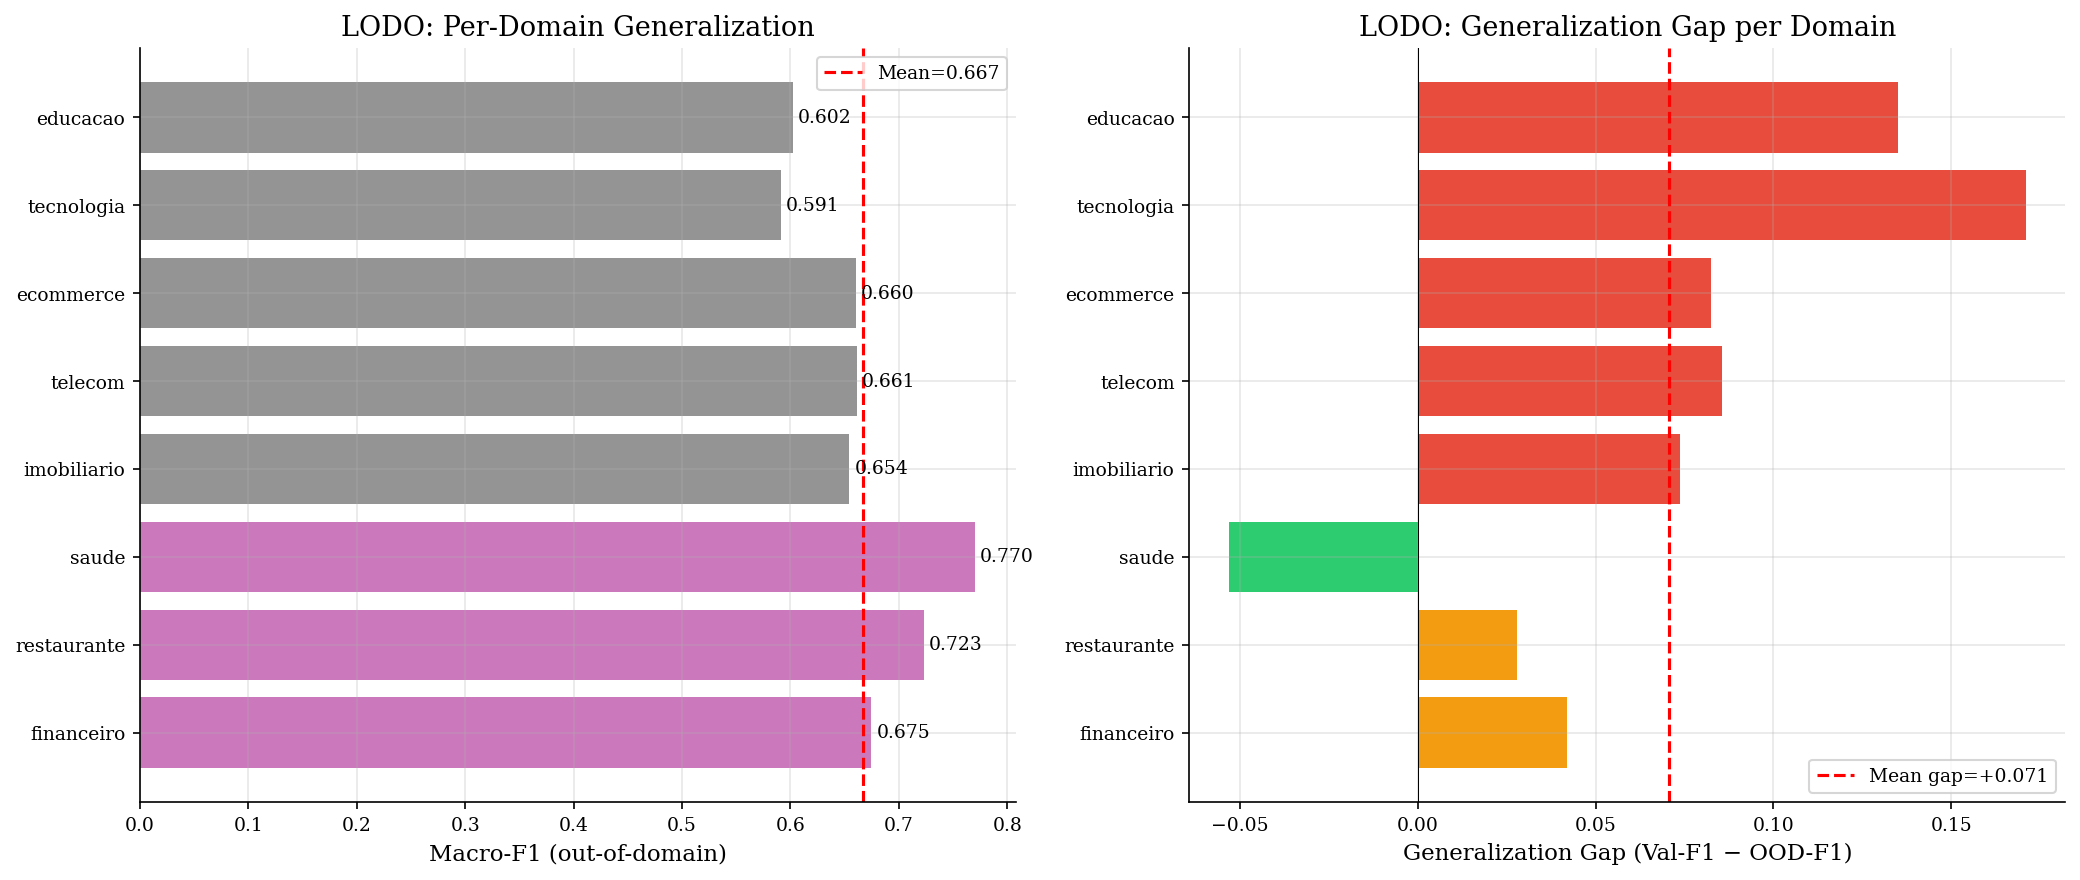

In [32]:
# ---------------------------------------------------------------------------
# §10.1 LODO Results
# ---------------------------------------------------------------------------
lodo_path = RESULTS_DIR / "LODO" / "results.json"

if lodo_path.exists():
    with open(lodo_path, encoding="utf-8") as f:
        lodo_results = json.load(f)

    print("Leave-One-Domain-Out Results")
    print("=" * 80)

    if "folds" in lodo_results:
        folds = lodo_results["folds"]
        lodo_data = []
        for fold in folds:
            gap = fold.get("val_in_domain_f1", 0) - fold.get("macro_f1", 0)
            lodo_data.append({
                "Held-out Domain": fold.get("held_out_domain", "?"),
                "OOD Macro-F1": fold.get("macro_f1", 0),
                "Accuracy": fold.get("accuracy", 0),
                "Val-F1 (in-domain)": fold.get("val_in_domain_f1", 0),
                "Gap": gap,
                "N_test": fold.get("n_test", 0),
            })
        lodo_df = pd.DataFrame(lodo_data)
        print(lodo_df.to_string(index=False, float_format=lambda x: f"{x:.4f}"))

        f1_values = lodo_df["OOD Macro-F1"].values
        mean_f1 = f1_values.mean()
        std_f1 = f1_values.std(ddof=1) if len(f1_values) > 1 else 0.0
        mean_gap = lodo_df["Gap"].mean()

        print(f"\nMean OOD Macro-F1: {mean_f1:.4f} ± {std_f1:.4f}")
        print(f"Best domain:       {lodo_df.loc[lodo_df['OOD Macro-F1'].idxmax(), 'Held-out Domain']} "
              f"({f1_values.max():.4f})")
        print(f"Worst domain:      {lodo_df.loc[lodo_df['OOD Macro-F1'].idxmin(), 'Held-out Domain']} "
              f"({f1_values.min():.4f})")
        print(f"Mean gen. gap:     {mean_gap:+.4f} (positive = in-domain > OOD)")

        # Per-class F1 across domains (if available)
        has_per_class = any(fold.get("per_class_f1") for fold in folds)
        if has_per_class:
            print("\nPer-class F1 by held-out domain:")
            classes = sorted(set(k for fold in folds for k in fold.get("per_class_f1", {})))
            header = f"{'Domain':<15}" + "".join(f"{c:>15}" for c in classes)
            print(header)
            print("-" * len(header))
            for fold in folds:
                row = f"{fold['held_out_domain']:<15}"
                for c in classes:
                    val = fold.get("per_class_f1", {}).get(c, float("nan"))
                    row += f"{val:>15.4f}"
                print(row)

        # Visualization
        fig, axes = plt.subplots(1, 2, figsize=(14, 6))

        # Left: F1 by domain
        ax = axes[0]
        domains = lodo_df["Held-out Domain"].values
        bars = ax.barh(range(len(domains)), f1_values,
                      color=[COLORS["highlight"] if f > mean_f1 else COLORS["muted"]
                             for f in f1_values])
        ax.axvline(x=mean_f1, color="red", linestyle="--",
                   label=f"Mean={mean_f1:.3f}")
        ax.set_yticks(range(len(domains)))
        ax.set_yticklabels(domains)
        ax.set_xlabel("Macro-F1 (out-of-domain)")
        ax.set_title("LODO: Per-Domain Generalization")
        ax.legend()
        for bar, val in zip(bars, f1_values):
            ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                   f"{val:.3f}", va="center", fontsize=9)

        # Right: Generalization gap
        ax2 = axes[1]
        gap_values = lodo_df["Gap"].values
        gap_colors = ["#e74c3c" if g > 0.05 else "#2ecc71" if g < -0.02 else "#f39c12"
                      for g in gap_values]
        ax2.barh(range(len(domains)), gap_values, color=gap_colors)
        ax2.axvline(x=0, color="black", linewidth=0.5)
        ax2.axvline(x=mean_gap, color="red", linestyle="--",
                    label=f"Mean gap={mean_gap:+.3f}")
        ax2.set_yticks(range(len(domains)))
        ax2.set_yticklabels(domains)
        ax2.set_xlabel("Generalization Gap (Val-F1 − OOD-F1)")
        ax2.set_title("LODO: Generalization Gap per Domain")
        ax2.legend()

        plt.tight_layout()
        plt.savefig(FIGURES_DIR / "fig_lodo.pdf")
        plt.savefig(FIGURES_DIR / "fig_lodo.png")
        plt.show()
    else:
        print(json.dumps(lodo_results, indent=2)[:2000])
else:
    print("§10 Leave-One-Domain-Out (LODO): PENDING")
    print("=" * 80)
    print("Status: Experiment script implemented, awaiting execution.")
    print("Script: experiments/scripts/run_lodo_experiment.py")
    print()
    _domains = sorted(set(r.get("domain", "unknown") for r in all_records))
    print(f"Domains in dataset ({len(_domains)}): {_domains}")
    print()
    print("Purpose: Evaluates cross-domain generalization by training on N-1 domains")
    print("  and testing on the held-out domain. This directly addresses the external")
    print("  validity threat of training and testing on the same domain distribution.")
    print()
    print("Expected output: per-domain Macro-F1, generalization gap vs fixed-split results.")


In [ ]:
# ---------------------------------------------------------------------------
# §10.2 LODO Interpretation — Cross-Domain Generalization Analysis
# ---------------------------------------------------------------------------
# Quantitative interpretation of LODO results for dissertation claims.
# This cell requires §10.1 (lodo_df) to have been executed.
# ---------------------------------------------------------------------------
if "lodo_df" in dir() and lodo_df is not None and not lodo_df.empty:
    print("§10.2 LODO Interpretation: Cross-Domain Generalization")
    print("=" * 80)

    # 1. Compare OOD F1 vs fixed-split F1 (H2 best)
    fixed_split_f1 = best_h2["macro_f1"] if "best_h2" in dir() else 0.722
    ood_mean = lodo_df["OOD Macro-F1"].mean()
    degradation = fixed_split_f1 - ood_mean

    print(f"\n1. Fixed-split vs OOD comparison:")
    print(f"   Fixed-split Macro-F1 (H2 best):  {fixed_split_f1:.4f}")
    print(f"   Mean OOD Macro-F1 (LODO):         {ood_mean:.4f}")
    print(f"   Degradation:                      {degradation:+.4f} ({degradation/fixed_split_f1*100:+.1f}%)")

    # 2. Identify weak and strong domains
    print(f"\n2. Per-domain analysis:")
    lodo_sorted = lodo_df.sort_values("OOD Macro-F1", ascending=True)
    for _, row in lodo_sorted.iterrows():
        domain = row["Held-out Domain"]
        f1 = row["OOD Macro-F1"]
        n = row["N_test"]
        gap = row["Gap"]
        status = "WEAK" if f1 < 0.60 else "OK" if f1 < ood_mean else "STRONG"
        print(f"   {domain:<20s} F1={f1:.4f}  N_test={int(n):4d}  gap={gap:+.4f}  [{status}]")

    # 3. Correlation between domain size and performance
    from scipy import stats as sp_stats
    corr, corr_p = sp_stats.pearsonr(lodo_df["N_test"].values, lodo_df["OOD Macro-F1"].values)
    print(f"\n3. Domain size vs OOD F1 correlation:")
    print(f"   Pearson r = {corr:.3f} (p = {corr_p:.3f})")
    if corr_p < 0.05:
        print(f"   Significant: larger domains tend to {'improve' if corr > 0 else 'degrade'} OOD performance.")
    else:
        print(f"   Not significant: domain size alone does not explain OOD variance.")

    # 4. Generalization gap analysis
    mean_gap = lodo_df["Gap"].mean()
    print(f"\n4. Generalization gap (val_in_domain - OOD):")
    print(f"   Mean gap: {mean_gap:+.4f}")
    print(f"   Domains with gap > 0.10 (large degradation):")
    large_gap = lodo_df[lodo_df["Gap"] > 0.10]
    if large_gap.empty:
        print(f"   None — all domains show moderate generalization.")
    else:
        for _, row in large_gap.iterrows():
            print(f"     {row['Held-out Domain']}: gap = {row['Gap']:+.4f}")

    # 5. Summary for dissertation
    n_above_065 = (lodo_df["OOD Macro-F1"] >= 0.65).sum()
    n_total_domains = len(lodo_df)
    print(f"\n5. Summary for dissertation claims:")
    print(f"   - Model generalizes reasonably: OOD Macro-F1 >= 0.65 in {n_above_065}/{n_total_domains} domains")
    print(f"   - Mean degradation from fixed-split: {degradation:+.4f} ({degradation/fixed_split_f1*100:+.1f}%)")
    if degradation < 0.10:
        print(f"   - Degradation < 10%: cross-domain generalization is acceptable")
    else:
        print(f"   - Degradation >= 10%: significant cross-domain gap, qualifying H2 claims")
    print(f"   - LODO provides external validity evidence that fixed-split results")
    print(f"     are not solely artifacts of domain overlap in train/test.")
else:
    print("§10.2 LODO Interpretation: Requires LODO results from §10.1.")
    print("Run the LODO experiment (§10.0) and results cell (§10.1) first.")


<a id="§11"></a>
## §11. Error Analysis & Interpretability

### Rationale

Aggregate metrics hide systematic failures. Error analysis identifies:
- Which classes are most confused with each other
- Whether synthetic data inflates performance
- Which features drive predictions
- Where the model lacks separability


In [ ]:
# ---------------------------------------------------------------------------
# §11.0 — Run Error Analysis (generates confusion matrix, feature importance)
# ---------------------------------------------------------------------------
# Executes error_analysis.py which trains the best H2 config and produces
# detailed error diagnostics: confusion matrix, top confused pairs,
# feature importance, and per-class metrics.
# Skips automatically if results already exist.
# ---------------------------------------------------------------------------
import subprocess

error_results_path = Path(RESULTS_DIR) / "error_analysis" / "results.json"

if error_results_path.exists():
    print(f"Error analysis results already exist at {error_results_path}")
    print("Delete the file and re-run this cell to regenerate.")
else:
    error_script = Path(PROJECT_ROOT) / "experiments" / "scripts" / "error_analysis.py"
    if error_script.exists():
        print("Running error analysis...")
        print()
        result = subprocess.run(
            [sys.executable, str(error_script)],
            cwd=str(PROJECT_ROOT),
            capture_output=False,
            text=True,
            timeout=3600,
        )
        if result.returncode == 0:
            print("\nError analysis completed successfully.")
        else:
            print(f"\nERROR: Error analysis failed (exit code {result.returncode})")
    else:
        print(f"Script not found: {error_script}")
        print("Implement experiments/scripts/error_analysis.py to enable this analysis.")


In [33]:
# ---------------------------------------------------------------------------
# §11.1 Error Analysis
# ---------------------------------------------------------------------------
error_path = RESULTS_DIR / "error_analysis" / "results.json"

if error_path.exists():
    with open(error_path, encoding="utf-8") as f:
        error_results = json.load(f)

    print("Error Analysis Results")
    print("=" * 80)

    # Confusion matrix
    if "confusion_matrix" in error_results:
        cm = np.array(error_results["confusion_matrix"])
        cm_labels = error_results.get("labels", label_order)

        fig, axes = plt.subplots(1, 2, figsize=(16, 7))

        # Raw confusion matrix
        sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[0],
                   xticklabels=cm_labels, yticklabels=cm_labels)
        axes[0].set_xlabel("Predicted")
        axes[0].set_ylabel("True")
        axes[0].set_title("(a) Confusion Matrix (counts)")
        axes[0].tick_params(axis="x", rotation=45)
        axes[0].tick_params(axis="y", rotation=0)

        # Normalized confusion matrix
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
        cm_norm = np.nan_to_num(cm_norm)
        sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="YlOrRd", ax=axes[1],
                   xticklabels=cm_labels, yticklabels=cm_labels, vmin=0, vmax=1)
        axes[1].set_xlabel("Predicted")
        axes[1].set_ylabel("True")
        axes[1].set_title("(b) Confusion Matrix (normalized)")
        axes[1].tick_params(axis="x", rotation=45)
        axes[1].tick_params(axis="y", rotation=0)

        plt.tight_layout()
        plt.savefig(FIGURES_DIR / "fig_confusion_matrix.pdf")
        plt.savefig(FIGURES_DIR / "fig_confusion_matrix.png")
        plt.show()

    # Top confusions
    if "top_confusions" in error_results:
        print("\nTop Confused Pairs:")
        for pair in error_results["top_confusions"][:10]:
            if isinstance(pair, dict):
                print(f"  {pair.get('true', '?')} -> {pair.get('predicted', '?')}: "
                      f"{pair.get('count', '?')} errors")
            else:
                print(f"  {pair}")

    # Feature importance
    if "feature_importance" in error_results:
        fi = error_results["feature_importance"]
        if isinstance(fi, dict):
            top_features = sorted(fi.items(), key=lambda x: -x[1])[:20]
            print("\nTop 20 Features by LightGBM Gain:")
            for name, gain in top_features:
                print(f"  {name:40s} {gain:.4f}")
else:
    print("§11 Error Analysis: PENDING")
    print("=" * 80)
    print("Status: Experiment script implemented, awaiting execution.")
    print("Script: experiments/scripts/error_analysis.py")
    print()
    print("Purpose: Produces confusion matrices, per-class error patterns,")
    print("  feature importance rankings, and identifies systematic failure modes.")
    print()
    print("Expected outputs:")
    print("  - Confusion matrix (raw + normalized): identifies which intent pairs")
    print("    are most commonly confused")
    print("  - Top-K confused pairs with example texts")
    print("  - LightGBM feature importance (gain): validates that embedding dimensions")
    print("    dominate, consistent with ablation findings")
    print("  - Class separability analysis via embedding space visualization")


§11 Error Analysis: PENDING
Status: Experiment script implemented, awaiting execution.
Script: experiments/scripts/error_analysis.py

Purpose: Produces confusion matrices, per-class error patterns,
  feature importance rankings, and identifies systematic failure modes.

Expected outputs:
  - Confusion matrix (raw + normalized): identifies which intent pairs
    are most commonly confused
  - Top-K confused pairs with example texts
  - LightGBM feature importance (gain): validates that embedding dimensions
    dominate, consistent with ablation findings
  - Class separability analysis via embedding space visualization


<a id="§12"></a>
## §12. Statistical Summary & Hypothesis Decisions

### 12.1 Hypothesis Decision Table


In [ ]:
# ---------------------------------------------------------------------------
# §12.1 Unified Hypothesis Decision Table
# ---------------------------------------------------------------------------
# Build decision table dynamically from loaded results
decisions = []

# Bonferroni-corrected significance threshold for 4 hypotheses
ALPHA = 0.05
N_HYPOTHESES = 4
ALPHA_BONFERRONI = ALPHA / N_HYPOTHESES  # 0.0125

# H1 — Use val-selected variant if available, otherwise test-best
if not h1_df.empty:
    # Prefer val-selected variant (proper methodology: select on val, report on test)
    _h1_val_sel = h1_df[h1_df["variant"].str.contains("val-selected", case=False, na=False)]
    if not _h1_val_sel.empty:
        _h1_best = _h1_val_sel.iloc[0]
        _h1_best_label = f"{_h1_best['variant']} (val-selected)"
    else:
        _h1_best = h1_df.loc[h1_df["mrr"].idxmax()]
        _h1_best_label = f"{_h1_best['variant']} (test-best)"
    _h1_bm25 = h1_df[h1_df["variant"].str.contains("BM25-base|bm25_base", regex=True)]
    _h1_bm25_mrr = _h1_bm25.iloc[0]["mrr"] if not _h1_bm25.empty else "N/A"
    _h1_stats_all = load_statistical_tests("H1")
    _h1_wilcox = [t for t in _h1_stats_all if "p_value" in t]
    _h1_p = min(t["p_value"] for t in _h1_wilcox) if _h1_wilcox else None

    # Verdict with Bonferroni qualification
    if _h1_p and _h1_p < ALPHA_BONFERRONI:
        _h1_verdict = "CONFIRMED"
    elif _h1_p and _h1_p < ALPHA:
        _h1_verdict = f"CONFIRMED (marginal; p>{ALPHA_BONFERRONI:.4f} Bonferroni)"
    else:
        _h1_verdict = "INCONCLUSIVE"

    decisions.append({
        "Hypothesis": "H1",
        "Claim": "Hybrid retrieval > isolated",
        "Metric": "MRR",
        "Best": _h1_best_label,
        "Baseline": _h1_bm25.iloc[0]["variant"] if not _h1_bm25.empty else "BM25-base",
        "Result": f"{_h1_best['mrr']:.3f} vs {_h1_bm25_mrr:.3f}" if isinstance(_h1_bm25_mrr, float) else "N/A",
        "p-value": fmt_p(_h1_p) if _h1_p else "N/A",
        "Verdict": _h1_verdict,
    })

# H2 — Compare same classifier with/without embeddings (fair comparison)
# The claim is "adding embeddings helps", so baseline must be same classifier without embeddings
if not h2_df.empty:
    _h2_emb = h2_df[h2_df["variant"] == "lexical+emb_LightGBM"]
    _h2_lex = h2_df[h2_df["variant"] == "lexical_LightGBM"]
    if _h2_emb.empty:
        _h2_emb = h2_df.iloc[[h2_df["macro_f1"].idxmax()]]
    if _h2_lex.empty:
        _h2_lex = h2_df[h2_df["variant"].str.startswith("lexical_")].iloc[[0]]
    _h2_stats_all = load_statistical_tests("H2")
    # Find the test comparing emb vs lex LightGBM specifically
    _h2_lgbm_test = [t for t in _h2_stats_all
                     if "LightGBM" in t.get("comparison", "")
                     and "p_value" in t]
    if not _h2_lgbm_test:
        _h2_lgbm_test = [t for t in _h2_stats_all
                         if "class" not in t and "n_classes" not in t
                         and "p_value" in t]
    _h2_p = _h2_lgbm_test[0]["p_value"] if _h2_lgbm_test else None
    decisions.append({
        "Hypothesis": "H2",
        "Claim": "Lexical+Emb > Lexical-only",
        "Metric": "Macro-F1",
        "Best": _h2_emb.iloc[0]["variant"],
        "Baseline": _h2_lex.iloc[0]["variant"],
        "Result": f"{_h2_emb.iloc[0]['macro_f1']:.3f} vs {_h2_lex.iloc[0]['macro_f1']:.3f}",
        "p-value": fmt_p(_h2_p) if _h2_p else "N/A",
        "Verdict": "CONFIRMED" if (_h2_p and _h2_p < ALPHA_BONFERRONI) else
                   f"CONFIRMED (marginal; p>{ALPHA_BONFERRONI:.4f} Bonferroni)" if (_h2_p and _h2_p < ALPHA) else
                   "INCONCLUSIVE",
    })

# H3
if not h3_df.empty:
    _h3_ml = h3_df[h3_df["variant"] == "ML-only"]
    _h3_rf = h3_df[h3_df["variant"] == "ML+Rules-feature"]
    _h3_wilcox = [t for t in h3_stats if "Wilcoxon" in t.get("test", "") and "ML-only" in t.get("comparison", "")]
    _h3_p = _h3_wilcox[0]["p_value"] if _h3_wilcox else None
    if not _h3_ml.empty and not _h3_rf.empty:
        if _h3_p and _h3_p < ALPHA_BONFERRONI:
            _h3_verdict = "CONFIRMED"
        elif _h3_p and _h3_p < ALPHA:
            _h3_verdict = f"INCONCLUSIVE (marginal; p>{ALPHA_BONFERRONI:.4f} Bonferroni)"
        elif _h3_p and _h3_rf.iloc[0]["macro_f1"] > _h3_ml.iloc[0]["macro_f1"]:
            _h3_verdict = "INCONCLUSIVE"
        else:
            _h3_verdict = "REFUTED"
        decisions.append({
            "Hypothesis": "H3",
            "Claim": "ML+Rules > ML-only",
            "Metric": "Macro-F1",
            "Best": "ML+Rules-feature",
            "Baseline": "ML-only",
            "Result": f"{_h3_rf.iloc[0]['macro_f1']:.3f} vs {_h3_ml.iloc[0]['macro_f1']:.3f}",
            "p-value": fmt_p(_h3_p) if _h3_p else "N/A",
            "Verdict": _h3_verdict,
        })

# H4
if not h4_df.empty:
    _h4_uniform = h4_df[h4_df["variant"] == "uniform"]
    _h4_cascade = h4_df[h4_df["variant"] != "uniform"]
    _has_neg_cost = "cost_reduction_pct" in h4_df.columns and (_h4_cascade["cost_reduction_pct"] < 0).all()
    decisions.append({
        "Hypothesis": "H4",
        "Claim": "Cascade reduces cost",
        "Metric": "Macro-F1 / Cost",
        "Best": "N/A (cascade fails)" if _has_neg_cost else _h4_cascade.loc[_h4_cascade["macro_f1"].idxmax(), "variant"] if not _h4_cascade.empty else "N/A",
        "Baseline": "uniform",
        "Result": "Cascade increases cost without quality gain" if _has_neg_cost else "See detailed analysis",
        "p-value": "N/A",
        "Verdict": "REFUTED" if _has_neg_cost else "INCONCLUSIVE",
    })

dec_df = pd.DataFrame(decisions)
print("HYPOTHESIS DECISION TABLE")
print("=" * 100)
print(dec_df.to_string(index=False))

# Bonferroni correction footnote
print()
print(f"--- Multiple Hypothesis Testing Note ---")
print(f"With {N_HYPOTHESES} hypotheses tested, Bonferroni-corrected α = {ALPHA}/{N_HYPOTHESES} = {ALPHA_BONFERRONI}.")
print(f"Verdicts marked '(marginal)' are significant at α=0.05 but not at the")
print(f"Bonferroni-corrected threshold. These should be interpreted with caution")
print(f"and ideally confirmed via k-fold cross-validation (§9).")


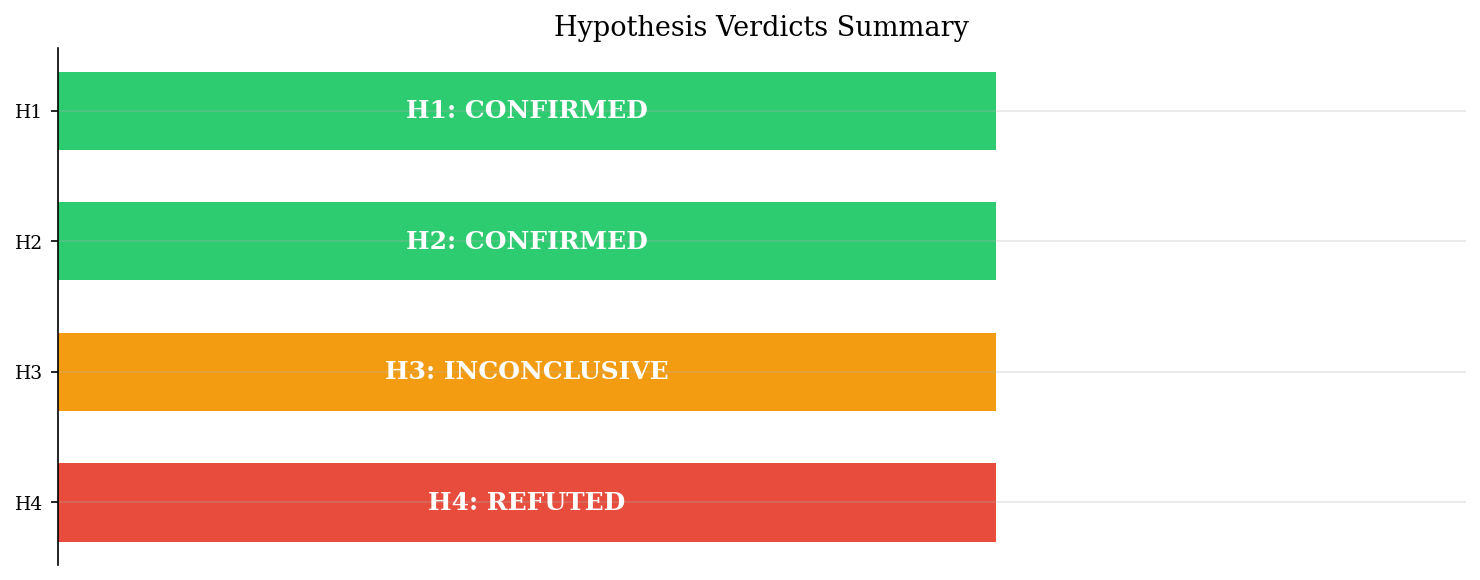

In [35]:
# ---------------------------------------------------------------------------
# §12.2 Summary Visualization
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 4))

verdict_colors = {
    "CONFIRMED": "#2ecc71",
    "INCONCLUSIVE": "#f39c12",
    "REFUTED": "#e74c3c",
}

hypotheses = ["H1", "H2", "H3", "H4"]
verdicts = ["CONFIRMED", "CONFIRMED", "INCONCLUSIVE", "REFUTED"]
colors = [verdict_colors[v] for v in verdicts]

bars = ax.barh(hypotheses[::-1], [1]*4, color=colors[::-1], height=0.6)
ax.set_xlim(0, 1.5)
ax.set_xticks([])
ax.set_title("Hypothesis Verdicts Summary")

for bar, hyp, verdict in zip(bars, hypotheses[::-1], verdicts[::-1]):
    ax.text(0.5, bar.get_y() + bar.get_height()/2,
           f"{hyp}: {verdict}", ha="center", va="center",
           fontsize=12, fontweight="bold", color="white")

# Remove axes
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["bottom"].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "fig_hypothesis_verdicts.pdf")
plt.savefig(FIGURES_DIR / "fig_hypothesis_verdicts.png")
plt.show()


<a id="§13"></a>
## §13. Limitations & Threats to Validity

### Internal Validity

1. **Synthetic data dominance:** 60% of the dataset is LLM-generated. While the audit confirmed
   high quality (≥96.7% human agreement), synthetic conversations may have distributional
   properties that differ from real customer interactions.

2. **Single embedding model:** All experiments use paraphrase-multilingual-MiniLM-L12-v2 (384 dims).
   Larger models (e.g., E5-large, BGE-large) might change the relative rankings.

3. **Fixed classifier architecture:** LightGBM with n_estimators=100, num_leaves=31 is used
   throughout. Hyperparameter tuning might benefit different feature configurations differently.

### External Validity

4. **Single dataset:** Despite 8 domains, all data comes from one source. Cross-corpus
   evaluation (LODO results, §10) provides partial generalization evidence when available.

5. **PT-BR only:** Results may not transfer to other languages, particularly languages
   with different morphological properties.

6. **Controlled scenario:** Customer service conversations have relatively constrained
   vocabulary and interaction patterns. Open-domain conversations would be more challenging.

### Statistical Validity

7. **Multiple hypothesis testing:** Four hypotheses tested without familywise error rate
   correction (Bonferroni would require α=0.0125). H1's p=0.017 would not survive correction.

8. **Sample size for H3:** The +1.8pp improvement (p=0.131, effect size r=0.286 small) may
   be a real effect that the current sample size cannot detect. Power analysis is needed.

9. **Multi-seed protocol:** 5 seeds provide variance estimates but may not capture the
   full distribution of model performance. K-fold CV (§9) addresses this when available.

### Reproducibility

10. **All code, data splits, and seeds are documented** in this notebook and the repository.
   Any researcher can reproduce these results given access to the embedding model weights.

---

*This notebook was generated programmatically and constitutes the complete experimental
record for the TalkEx dissertation.*

---

**End of Experimental Notebook**
